# 🦴 Bone Fracture AI Pipeline — Notebook E: Full Pipeline + Grad-CAM + Model Comparison
### Computer Vision Final Project · Saint Joseph University · Spring 2026
### Project Version: CV_project_v4

---

## Notebook Structure

```
Part 1 — Setup & EfficientNet (Sections 1–4)
    Section 1: Install & Imports
    Section 2: Mount Drive & Load All Models
    Section 3: EfficientNet-B3 Test Set Evaluation
    Section 4: Grad-CAM Visualization

Part 2 — YOLOv8 (Section 5)
    5.1 Filter test set to hand + leg only
    5.2 Official mAP metrics
    5.3 Ground truth bounding boxes
    5.4 YOLOv8 predictions on validation set
    5.5 Full 3-stage pipeline visualization
    5.6 Missed detections (failure cases)
    5.7 Demo single image

Part 3 — Faster R-CNN (Section 6)
    6.1 Download & load Faster R-CNN
    6.2 Run inference + filter hand/leg
    6.3 Ground truth bounding boxes
    6.4 Faster R-CNN predictions on validation set
    6.5 Full 3-stage pipeline visualization (FRCNN version)
    6.6 Missed detections (failure cases)
    6.7 Demo single image

Part 4 — Model Comparison (Section 7)
    7.1 Side-by-side visual comparison
    7.2 Quantitative metrics table
    7.3 Bar charts
    7.4 Scientific discussion

Part 5 — Summary (Section 8)
    8.1 Final report figures
    8.2 Project summary
```


---
## 📦 Section 1 — Install & Imports

In [1]:
!pip install -q ultralytics grad-cam scikit-learn matplotlib seaborn pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 72.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.1 MB/s eta 0:00:00


In [2]:
import os, json, random, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from pathlib import Path
from collections import Counter
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from torchvision.models import EfficientNet_B3_Weights
from ultralytics import YOLO

from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    accuracy_score
)

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = torch.cuda.is_available()
print(f'✅ All libraries imported')
print(f'✅ Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ All libraries imported
✅ Device: cuda
   GPU: Tesla T4


In [3]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
print('✅ Truncated image tolerance enabled')

✅ Truncated image tolerance enabled


---
## ⚙️ Section 2 — Mount Drive & Load All Models

Loads both trained models and all configuration from previous notebooks.

In [4]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Drive mounted.')

Mounted at /content/drive
✅ Drive mounted.


In [5]:
# ── Load dataset config (from Notebook A) ────────────────────────
CONFIG_PATH = Path('/content/drive/MyDrive/CV_project_v4/dataset_config.json')
if not CONFIG_PATH.exists():
    raise FileNotFoundError('dataset_config.json not found. Run Notebook A first.')
with open(CONFIG_PATH) as f:
    cfg = json.load(f)

PROJECT_ROOT     = Path(cfg['project_root'])
CLF_TEST_DIR     = Path(cfg['clf_test_dir'])
DET_ROOT         = Path(cfg['det_root'])
OUTPUT_DIR       = Path(cfg['output_dir'])
YOLO_YAML        = Path(cfg['det_yaml'])
YOLO_BEST_PATH   = Path(cfg.get('yolo_best_weights',
                    str(PROJECT_ROOT/'best_yolov8_fracture.pt')))
YOLO_IMG_SIZE    = cfg.get('yolo_img_size', 640)
CONF_THRESH      = cfg.get('yolo_conf_thresh', 0.25)
IOU_THRESH       = cfg.get('yolo_iou_thresh', 0.45)

# ── Load class info (from Notebook B) ────────────────────────────
INFO_PATH = PROJECT_ROOT / 'class_info_v4.pkl'
if not INFO_PATH.exists():
    raise FileNotFoundError('class_info_v4.pkl not found. Run Notebook B first.')
with open(INFO_PATH, 'rb') as f:
    info = pickle.load(f)

NUM_CLASSES         = info['NUM_CLASSES']
ORDERED_CLASSES     = info['ORDERED_CLASSES']
CLASS_TO_IDX        = info['CLASS_TO_IDX']
IDX_TO_CLASS        = info['IDX_TO_CLASS']
saved_class_weights = info['class_weights']
IMG_SIZE            = info['IMG_SIZE']
BATCH_SIZE          = info['BATCH_SIZE']
NUM_WORKERS         = info['NUM_WORKERS']
IMAGENET_MEAN       = info['IMAGENET_MEAN']
IMAGENET_STD        = info['IMAGENET_STD']
eval_transform      = info['eval_transform']

# Output folders
FINAL_FIG_DIR = OUTPUT_DIR / 'final_pipeline'
FINAL_FIG_DIR.mkdir(parents=True, exist_ok=True)

print('✅ Config and class info loaded')
print(f'   Classes:     {NUM_CLASSES} → {ORDERED_CLASSES}')
print(f'   Test dir:    {CLF_TEST_DIR}')
print(f'   EfficientNet checkpoint exists: {(PROJECT_ROOT/"best_efficientnet_b3_v4.pth").exists()}')
print(f'   YOLOv8 checkpoint exists:       {YOLO_BEST_PATH.exists()}')

✅ Config and class info loaded
   Classes:     4 → ['hand_fractured', 'hand_normal', 'leg_fractured', 'leg_normal']
   Test dir:    /content/drive/MyDrive/CV_project_v4/classification_dataset/test
   EfficientNet checkpoint exists: True
   YOLOv8 checkpoint exists:       True


In [6]:
# ── Load EfficientNet-B3 (from Notebook C) ────────────────────────
CLF_CKPT_PATH = PROJECT_ROOT / 'best_efficientnet_b3_v4.pth'

def build_efficientnet_b3(num_classes, dropout=0.4):
    model = models.efficientnet_b3(weights=None)  # no pretrained — we load our weights
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout, inplace=True),
        nn.Linear(in_features, num_classes)
    )
    return model

clf_model = build_efficientnet_b3(NUM_CLASSES)
ckpt      = torch.load(CLF_CKPT_PATH, map_location=DEVICE)
clf_model.load_state_dict(ckpt['model_state_dict'])
clf_model = clf_model.to(DEVICE)
clf_model.eval()

print(f'✅ EfficientNet-B3 loaded — best epoch {ckpt["epoch"]}')
print(f'   Val F1 at training:  {ckpt["val_f1"]:.4f}')
print(f'   Val Acc at training: {ckpt["val_acc"]:.2%}')

# ── Load YOLOv8 (from Notebook D) ────────────────────────────────
det_model = YOLO(str(YOLO_BEST_PATH))
print(f'\n✅ YOLOv8 loaded from: {YOLO_BEST_PATH}')
print('\n✅ Both models ready for the full pipeline.')

✅ EfficientNet-B3 loaded — best epoch 45
   Val F1 at training:  0.6915
   Val Acc at training: 76.77%

✅ YOLOv8 loaded from: /content/drive/MyDrive/CV_project_v4/best_yolov8_fracture.pt

✅ Both models ready for the full pipeline.


---
## 🧪 Section 3 — EfficientNet Test Set Evaluation

**This is the only time we evaluate on the test set.**
The test set was never used during training or validation —
these numbers represent true, unbiased generalization performance.

Reports: accuracy, Macro F1, per-class precision/recall/F1, confusion matrix.

In [7]:
# Build test DataLoader
test_dataset = datasets.ImageFolder(root=str(CLF_TEST_DIR), transform=eval_transform)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

class_weights_tensor = torch.tensor(saved_class_weights, dtype=torch.float).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)

# Load optimal thresholds saved in Notebook C
best_thresholds = info.get('optimal_thresholds', [0.5]*NUM_CLASSES)
print(f'✅ Optimal thresholds loaded: {best_thresholds}')

# Full test evaluation
import torch.nn.functional as F

clf_model.eval()
all_probs_test, all_labels = [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            outputs = clf_model(imgs)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        all_probs_test.extend(probs)
        all_labels.extend(lbls.tolist())

all_probs_test = np.array(all_probs_test)

# Apply optimal thresholds
all_preds = np.argmax(all_probs_test, axis=1).copy()
for cls_idx, t in enumerate(best_thresholds):
    override = all_probs_test[:, cls_idx] > t
    all_preds[override] = cls_idx

test_acc = accuracy_score(all_labels, all_preds)
test_f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)

print('='*55)
print('  EfficientNet-B3 — TEST SET RESULTS (Final)')
print('='*55)
print(f'  Overall Accuracy:  {test_acc:.4f}  ({test_acc:.2%})')
print(f'  Macro F1:          {test_f1:.4f}')
print('='*55)
print()
print('📋 Per-class Classification Report:')
print(classification_report(all_labels, all_preds,
                             target_names=ORDERED_CLASSES, zero_division=0))

✅ Optimal thresholds loaded: [0.5, np.float64(0.32000000000000006), 0.5, np.float64(0.1)]
  EfficientNet-B3 — TEST SET RESULTS (Final)
  Overall Accuracy:  0.8663  (86.63%)
  Macro F1:          0.7625

📋 Per-class Classification Report:
                precision    recall  f1-score   support

hand_fractured       0.62      0.77      0.69        39
   hand_normal       0.90      0.79      0.84        91
 leg_fractured       0.54      0.59      0.57        22
    leg_normal       0.95      0.95      0.95       192

      accuracy                           0.87       344
     macro avg       0.75      0.78      0.76       344
  weighted avg       0.88      0.87      0.87       344



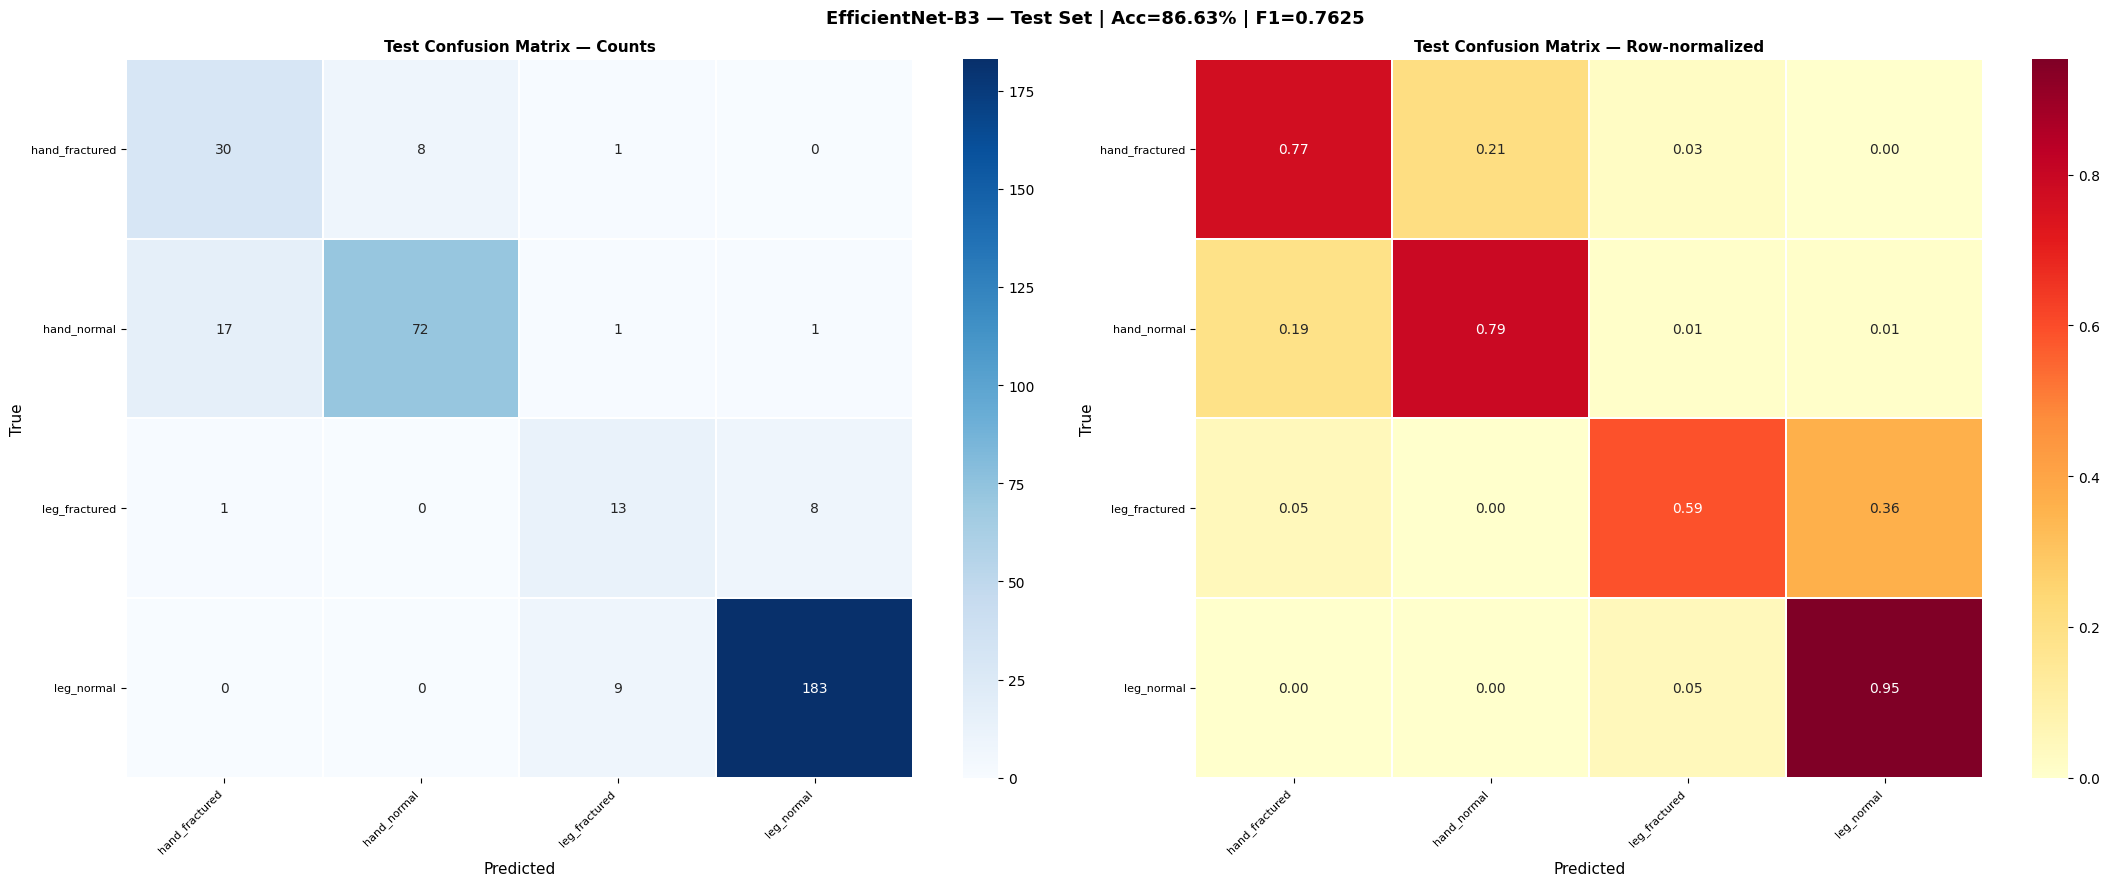

✅ Saved → test_confusion_matrix.png
✅ Saved → test_classification_report.csv


In [8]:
# Confusion matrix — test set
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
for ax, data, fmt, cmap, title in zip(
    axes, [cm, cm_norm], ['d','.2f'], ['Blues','YlOrRd'],
    ['Test Confusion Matrix — Counts', 'Test Confusion Matrix — Row-normalized']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=ORDERED_CLASSES, yticklabels=ORDERED_CLASSES,
                ax=ax, linewidths=0.3)
    ax.set_xlabel('Predicted', fontsize=11); ax.set_ylabel('True', fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.suptitle(f'EfficientNet-B3 — Test Set | Acc={test_acc:.2%} | F1={test_f1:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FINAL_FIG_DIR/'test_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Saved → test_confusion_matrix.png')

# Save classification report
report_dict = classification_report(all_labels, all_preds,
                                     target_names=ORDERED_CLASSES,
                                     output_dict=True, zero_division=0)
pd.DataFrame(report_dict).T.to_csv(FINAL_FIG_DIR/'test_classification_report.csv')
print('✅ Saved → test_classification_report.csv')

---
## 🔭 Section 4 — Grad-CAM Visualization

**Grad-CAM (Gradient-weighted Class Activation Mapping)** shows which regions
of the X-ray the EfficientNet-B3 model was focusing on when making its decision.

Warm colors (red/yellow) = high activation = model focused here  
Cool colors (blue) = low activation = model ignored this region

For a good model on X-rays: the heatmap should highlight the bone/fracture region,
not the image borders or background.

We target the **last convolutional layer** of EfficientNet-B3's feature extractor
(`features[-1]`) which produces the highest-level spatial features.

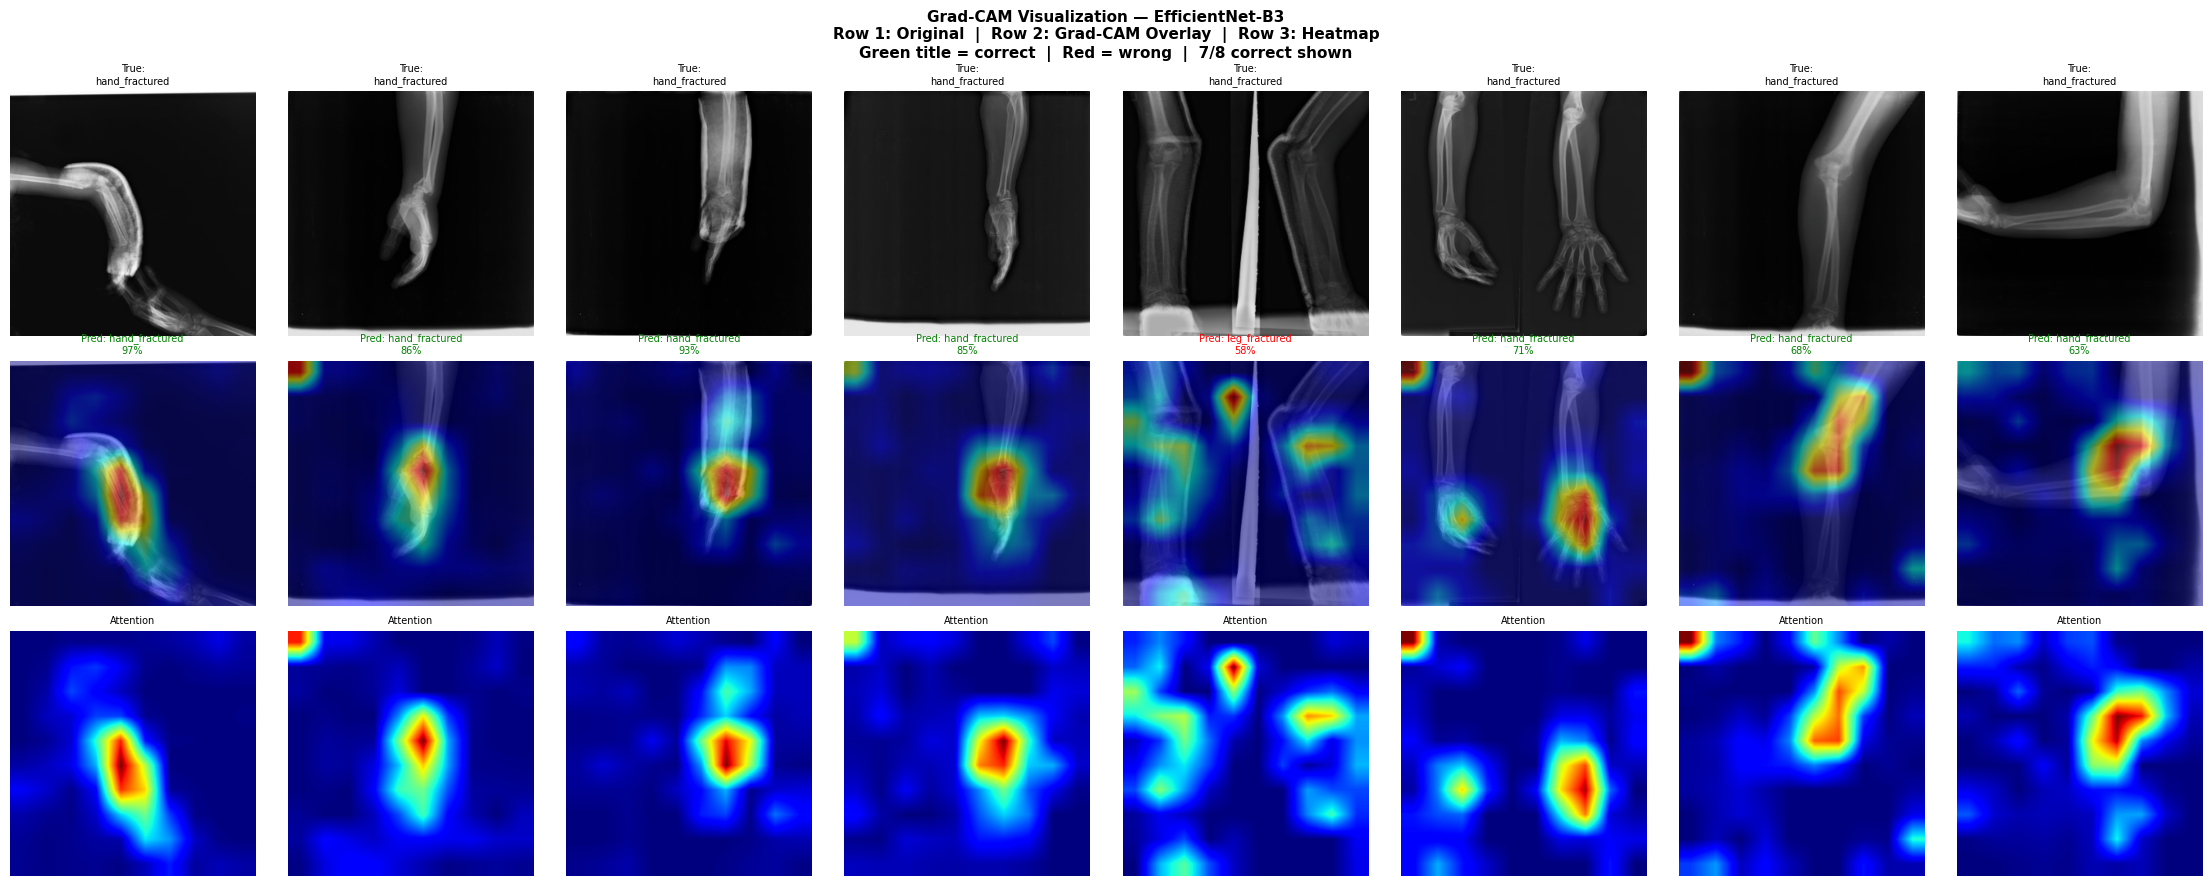

✅ Saved → gradcam_visualization.png


In [9]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

def denorm(t, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    out = t.clone()
    for i in range(3): out[i] = out[i]*std[i] + mean[i]
    return out.clamp(0, 1)

# Target the last MBConv block in EfficientNet-B3
# This is where the most semantically rich spatial features live
target_layers = [clf_model.features[-1]]
cam = GradCAM(model=clf_model, target_layers=target_layers)

# Get one batch from test loader
test_imgs, test_lbls = next(iter(test_loader))

n_show = min(8, len(test_imgs))
fig, axes = plt.subplots(3, n_show, figsize=(n_show * 2.8, 9))
correct_count = 0

for i in range(n_show):
    inp        = test_imgs[i:i+1].to(DEVICE)
    true_label = IDX_TO_CLASS[test_lbls[i].item()]

    # Grad-CAM heatmap
    grayscale_cam = cam(input_tensor=inp)[0]
    rgb_img       = denorm(test_imgs[i]).permute(1, 2, 0).numpy()
    cam_image     = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    # Prediction
    with torch.no_grad():
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            logits = clf_model(inp)
        probs     = torch.softmax(logits, dim=1)[0]
        pred_idx  = logits.argmax(1).item()
    pred_label  = IDX_TO_CLASS[pred_idx]
    confidence  = probs[pred_idx].item()
    is_correct  = pred_label == true_label
    if is_correct: correct_count += 1
    color = 'green' if is_correct else 'red'

    # Row 1: Original image
    axes[0, i].imshow(rgb_img)
    axes[0, i].set_title(f'True:\n{true_label}', fontsize=7)
    axes[0, i].axis('off')

    # Row 2: Grad-CAM overlay
    axes[1, i].imshow(cam_image)
    axes[1, i].set_title(f'Pred: {pred_label}\n{confidence:.0%}',
                          fontsize=7, color=color)
    axes[1, i].axis('off')

    # Row 3: Heatmap only
    axes[2, i].imshow(grayscale_cam, cmap='jet')
    axes[2, i].set_title('Attention', fontsize=7)
    axes[2, i].axis('off')

plt.suptitle(
    f'Grad-CAM Visualization — EfficientNet-B3\n'
    f'Row 1: Original  |  Row 2: Grad-CAM Overlay  |  Row 3: Heatmap\n'
    f'Green title = correct  |  Red = wrong  |  {correct_count}/{n_show} correct shown',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig(FINAL_FIG_DIR/'gradcam_visualization.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Saved → gradcam_visualization.png')

---
## 🎯 Section 5 — YOLOv8: Full Evaluation

All detection evaluations use **hand and leg images only**.
Reason: Stage 1 (EfficientNet) excludes hip and shoulder — those images
would never reach Stage 2 in the real pipeline. Evaluating on them
would create an inconsistency between classifier scope and detector scope.

| Step | Content | Saved as |
|---|---|---|
| 5.1 | Filter to hand+leg | — |
| 5.2 | Official mAP metrics | — |
| 5.3 | Ground truth boxes (val) | `yolo_gt_boxes.png` |
| 5.4 | YOLOv8 predictions (val) | `yolo_val_predictions.png` |
| 5.5 | Full 3-stage pipeline | `yolo_full_pipeline.png` |
| 5.6 | Missed detections | `yolo_missed_detections.png` |
| 5.7 | Demo single image | `yolo_demo.png` |


In [10]:
# ── 5.1 Filter detection images to hand + leg only ───────────────
import pandas as pd

FRAC_ROOT_PATH = Path(cfg.get('frac_root',
    '/content/drive/MyDrive/CV_project_v4/raw_dataset/FracAtlas'))
CSV_PATH = FRAC_ROOT_PATH / 'dataset.csv'
df_csv   = pd.read_csv(CSV_PATH)

hand_leg_ids = set(
    df_csv[(df_csv['hand']==1) | (df_csv['leg']==1)]['image_id']
    .str.replace('.jpg','', regex=False).tolist()
)

TEST_DET_DIR  = DET_ROOT / 'test'  / 'images'
VAL_DET_DIR   = DET_ROOT / 'val'   / 'images'
TEST_LBL_DIR  = DET_ROOT / 'test'  / 'labels'
VAL_LBL_DIR   = DET_ROOT / 'val'   / 'labels'

test_det_imgs = [p for p in TEST_DET_DIR.glob('*.jpg') if p.stem in hand_leg_ids]
val_det_imgs  = [p for p in VAL_DET_DIR.glob('*.jpg')  if p.stem in hand_leg_ids]

print('Detection dataset — hand + leg only:')
print(f'  Test images: {len(test_det_imgs)}')
print(f'  Val  images: {len(val_det_imgs)}')
print(f'  (Hip and shoulder excluded — consistent with Stage 1 scope)')


Detection dataset — hand + leg only:
  Test images: 135
  Val  images: 201
  (Hip and shoulder excluded — consistent with Stage 1 scope)


In [11]:
print('Running YOLOv8 evaluation on test set...')
test_metrics = det_model.val(
    data    = str(YOLO_YAML),
    split   = 'test',
    imgsz   = YOLO_IMG_SIZE,
    conf    = CONF_THRESH,
    iou     = IOU_THRESH,
    device  = str(DEVICE),
    verbose = True
)

yolo_map50   = test_metrics.box.map50
yolo_map5095 = test_metrics.box.map
yolo_prec    = test_metrics.box.mp
yolo_rec     = test_metrics.box.mr

print('\n=== YOLOv8 TEST METRICS ===')
print(f'  mAP@50:     {yolo_map50:.4f}')
print(f'  mAP@50-95:  {yolo_map5095:.4f}')
print(f'  Precision:  {yolo_prec:.4f}')
print(f'  Recall:     {yolo_rec:.4f}')

Running YOLOv8 evaluation on test set...
Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.4 ms, read: 0.3±0.6 MB/s, size: 106.0 KB)
val: Scanning /content/drive/MyDrive/CV_project_v4/detection_dataset/test/labels.cache... 144 images, 73 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 144/144 28.8Mit/s 0.0s
val: /content/drive/MyDrive/CV_project_v4/detection_dataset/test/images/IMG0004172.jpg: corrupt JPEG restored and saved
val: /content/drive/MyDrive/CV_project_v4/detection_dataset/test/images/IMG0004223.jpg: corrupt JPEG restored and saved
val: /content/drive/MyDrive/CV_project_v4/detection_dataset/test/images/IMG0004290.jpg: corrupt JPEG restored and saved
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.9s/it 16.7s
                   all        144         97      0.733   

### Step 5.3 — Ground Truth Bounding Boxes (Validation Set)

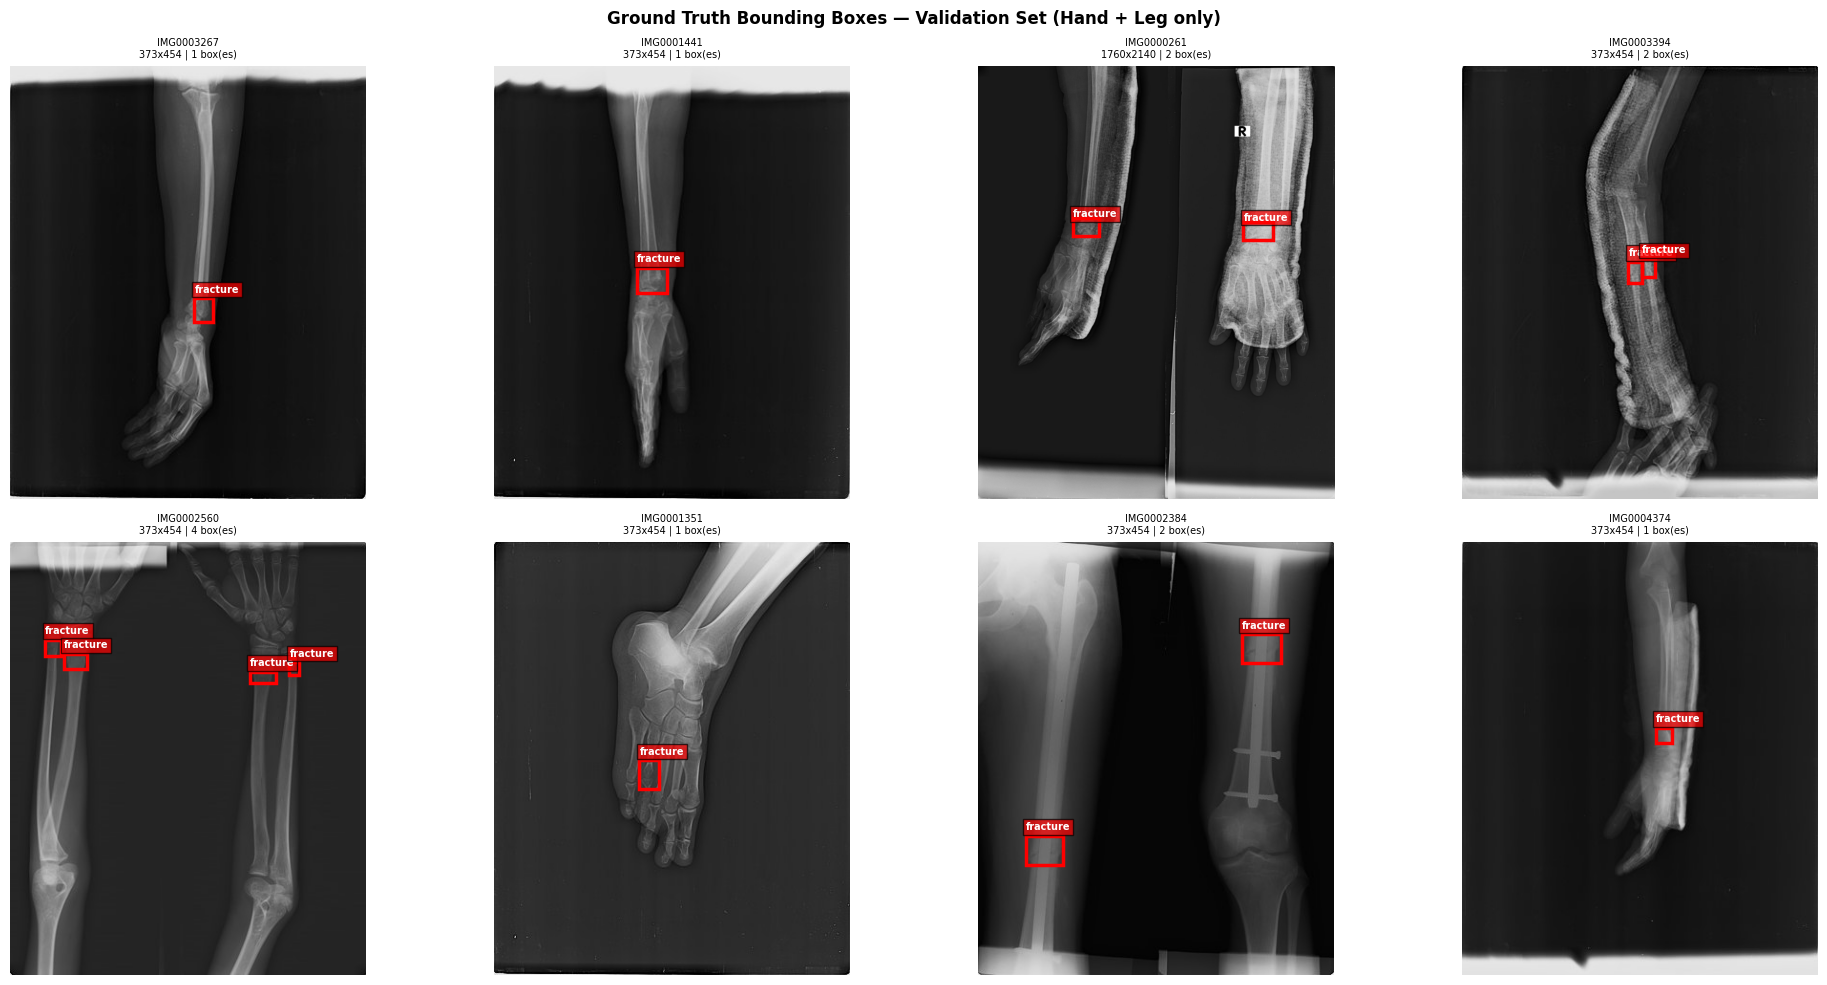

✅ Saved → yolo_gt_boxes.png


In [12]:
# ── Ground truth boxes — val set (hand + leg only) ───────────────
pos_val_yolo = [
    img for img in val_det_imgs
    if (VAL_LBL_DIR / (img.stem+'.txt')).exists()
    and (VAL_LBL_DIR / (img.stem+'.txt')).stat().st_size > 0
]
random.shuffle(pos_val_yolo)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, ax in enumerate(axes[:min(8, len(pos_val_yolo))]):
    img_path = pos_val_yolo[i]
    lbl_path = VAL_LBL_DIR / (img_path.stem + '.txt')
    img = Image.open(img_path).convert('RGB')
    W, H = img.size
    ax.imshow(img)
    n_boxes = 0
    with open(lbl_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                _, xc, yc, bw, bh = map(float, parts)
                x1 = (xc-bw/2)*W; y1 = (yc-bh/2)*H
                ax.add_patch(patches.Rectangle((x1,y1),bw*W,bh*H,
                    linewidth=2.5, edgecolor='red', facecolor='none'))
                ax.text(x1, y1-6, 'fracture', color='white', fontsize=7,
                        fontweight='bold', bbox=dict(facecolor='red',alpha=0.7,pad=2))
                n_boxes += 1
    ax.set_title(f'{img_path.stem[:15]}\n{W}x{H} | {n_boxes} box(es)', fontsize=7)
    ax.axis('off')

plt.suptitle('Ground Truth Bounding Boxes — Validation Set (Hand + Leg only)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FINAL_FIG_DIR/'yolo_gt_boxes.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Saved → yolo_gt_boxes.png')


### Step 5.4 — YOLOv8 Predictions vs Ground Truth (Validation Set)

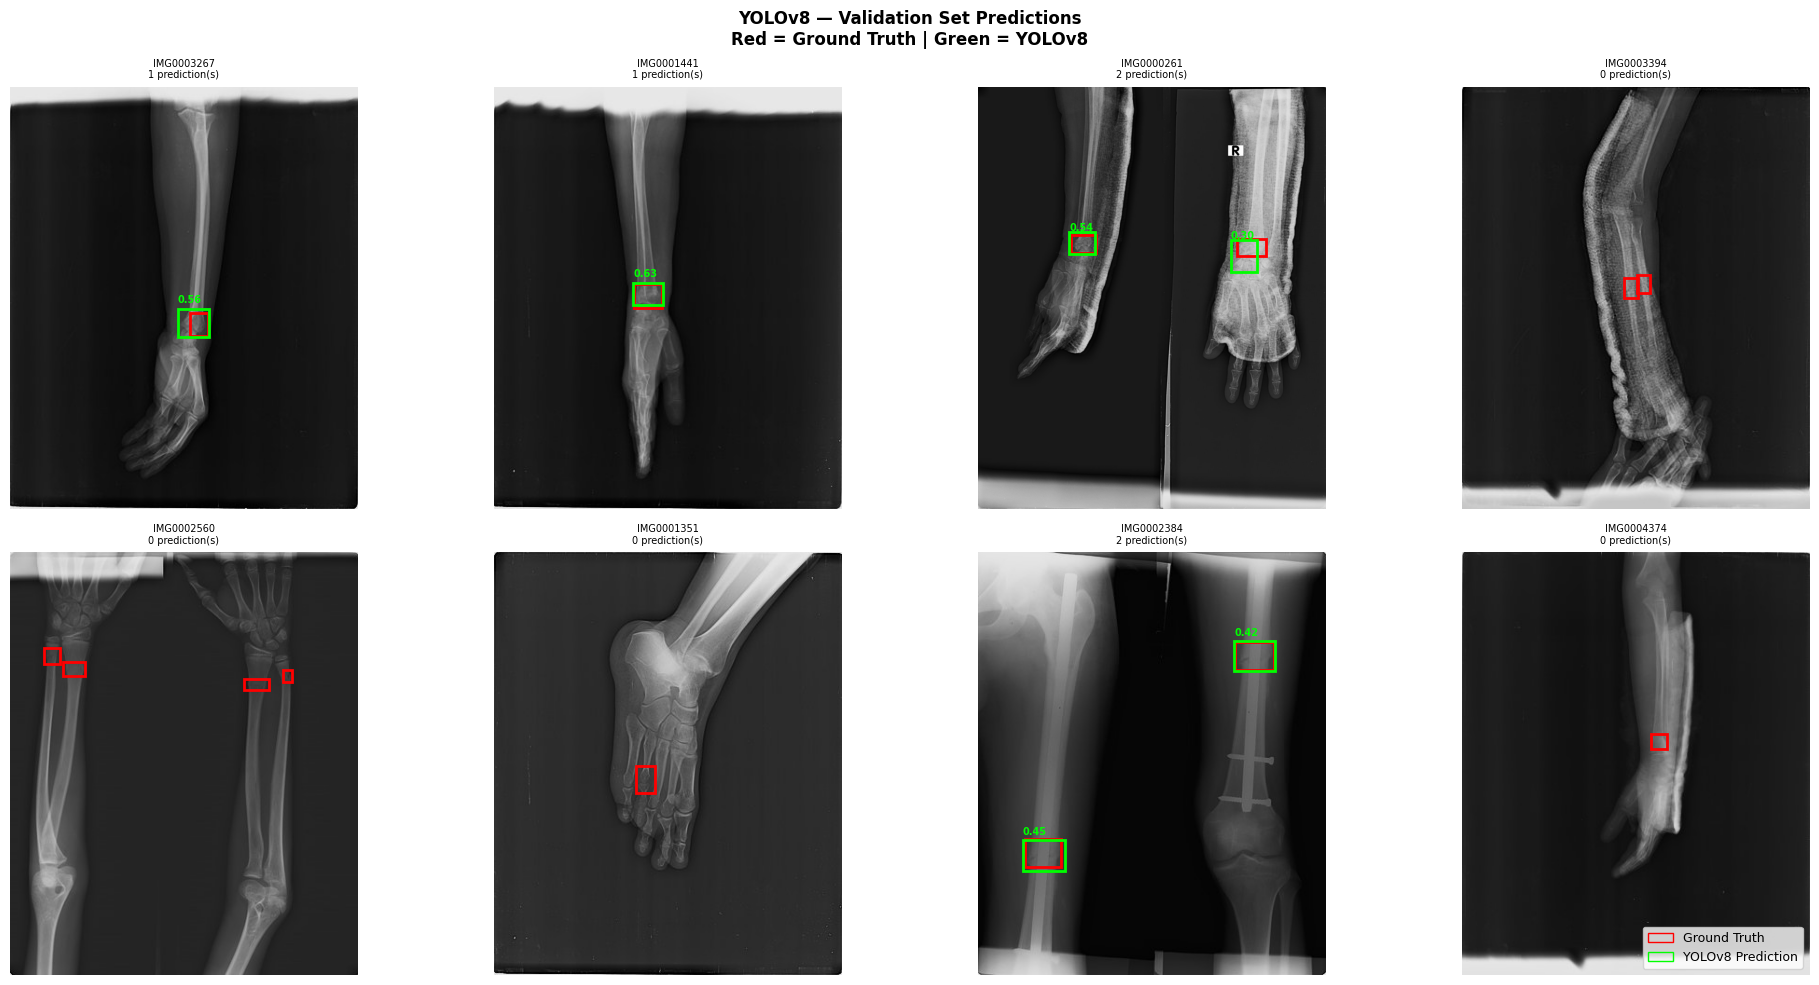

✅ Saved → yolo_val_predictions.png


In [13]:
# ── YOLOv8 predictions vs GT — val set ───────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, ax in enumerate(axes[:min(8, len(pos_val_yolo))]):
    img_path = pos_val_yolo[i]
    lbl_path = VAL_LBL_DIR / (img_path.stem + '.txt')
    img = Image.open(img_path).convert('RGB')
    W, H = img.size
    ax.imshow(img)
    # GT (red)
    with open(lbl_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                _, xc, yc, bw, bh = map(float, parts)
                x1=(xc-bw/2)*W; y1=(yc-bh/2)*H
                ax.add_patch(patches.Rectangle((x1,y1),bw*W,bh*H,
                    linewidth=2, edgecolor='red', facecolor='none'))
    # YOLO (green)
    preds = det_model.predict(str(img_path), conf=CONF_THRESH,
                               iou=IOU_THRESH, imgsz=YOLO_IMG_SIZE, verbose=False)
    n_pred = 0
    for det in preds[0].boxes:
        x1,y1,x2,y2 = det.xyxy[0].cpu().numpy()
        conf_s = float(det.conf[0])
        ax.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,
            linewidth=2, edgecolor='lime', facecolor='none'))
        ax.text(x1, y1-6, f'{conf_s:.2f}', color='lime', fontsize=7, fontweight='bold')
        n_pred += 1
    ax.set_title(f'{img_path.stem[:15]}\n{n_pred} prediction(s)', fontsize=7)
    ax.axis('off')

from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(facecolor='none', edgecolor='red',  label='Ground Truth'),
    Patch(facecolor='none', edgecolor='lime', label='YOLOv8 Prediction'),
], loc='lower right', fontsize=9)
plt.suptitle('YOLOv8 — Validation Set Predictions\nRed = Ground Truth | Green = YOLOv8',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FINAL_FIG_DIR/'yolo_val_predictions.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Saved → yolo_val_predictions.png')


### Step 5.5 — Full 3-Stage Pipeline Visualization (YOLOv8)

In [14]:
def run_full_pipeline(img_path, clf_model, det_model, eval_transform,
                      IDX_TO_CLASS, DEVICE, cam, IMG_SIZE,
                      YOLO_IMG_SIZE, CONF_THRESH, IOU_THRESH,
                      IMAGENET_MEAN, IMAGENET_STD,
                      best_thresholds=None):
    """
    Run the complete 3-stage pipeline on a single X-ray image.
    Returns: (original_img, cam_image, yolo_result_img, prediction_dict)
    """
    # ── Load image ────────────────────────────────────────────────
    pil_img = Image.open(img_path).convert('RGB')
    W, H    = pil_img.size

    # ── Stage 1: EfficientNet-B3 classification ───────────────────
    tensor  = eval_transform(pil_img).unsqueeze(0).to(DEVICE)
    clf_model.eval()
    with torch.no_grad():
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            logits = clf_model(tensor)
        probs    = torch.softmax(logits, dim=1)[0]
        pred_idx = logits.argmax(1).item()

    # Apply optimal thresholds from Notebook C
    if best_thresholds is not None:
        probs_np = probs.cpu().numpy()
        for i, t in enumerate(best_thresholds):
            if probs_np[i] > t:
                pred_idx = i
                break

    pred_label   = IDX_TO_CLASS[pred_idx]
    confidence   = probs[pred_idx].item()
    is_fractured = 'fractured' in pred_label
    body_part    = pred_label.replace('_fractured','').replace('_normal','')
    top3         = [(IDX_TO_CLASS[i], probs[i].item())
                    for i in probs.topk(3).indices.tolist()]

    # ── Stage 2: Grad-CAM ─────────────────────────────────────────
    grayscale_cam = cam(input_tensor=tensor)[0]

    def denorm_t(t):
        out = t.clone().squeeze(0)
        for i in range(3):
            out[i] = out[i]*IMAGENET_STD[i] + IMAGENET_MEAN[i]
        return out.clamp(0,1).permute(1,2,0).cpu().numpy()

    rgb_resized = denorm_t(tensor)
    cam_image   = show_cam_on_image(rgb_resized, grayscale_cam, use_rgb=True)

    # ── Stage 3: YOLOv8 detection (only if fractured) ─────────────
    yolo_boxes = []
    if is_fractured:
        preds = det_model.predict(str(img_path), conf=CONF_THRESH,
                                  iou=IOU_THRESH, imgsz=YOLO_IMG_SIZE,
                                  verbose=False)
        for det in preds[0].boxes:
            x1,y1,x2,y2 = det.xyxy[0].cpu().numpy()
            conf_score   = float(det.conf[0])
            yolo_boxes.append((x1,y1,x2,y2,conf_score))

    return {
        'pil_img':      pil_img,
        'cam_image':    cam_image,
        'rgb_resized':  rgb_resized,
        'pred_label':   pred_label,
        'body_part':    body_part,
        'is_fractured': is_fractured,
        'confidence':   confidence,
        'top3':         top3,
        'yolo_boxes':   yolo_boxes,
        'W': W, 'H': H
    }

print('✅ run_full_pipeline() defined')

✅ run_full_pipeline() defined


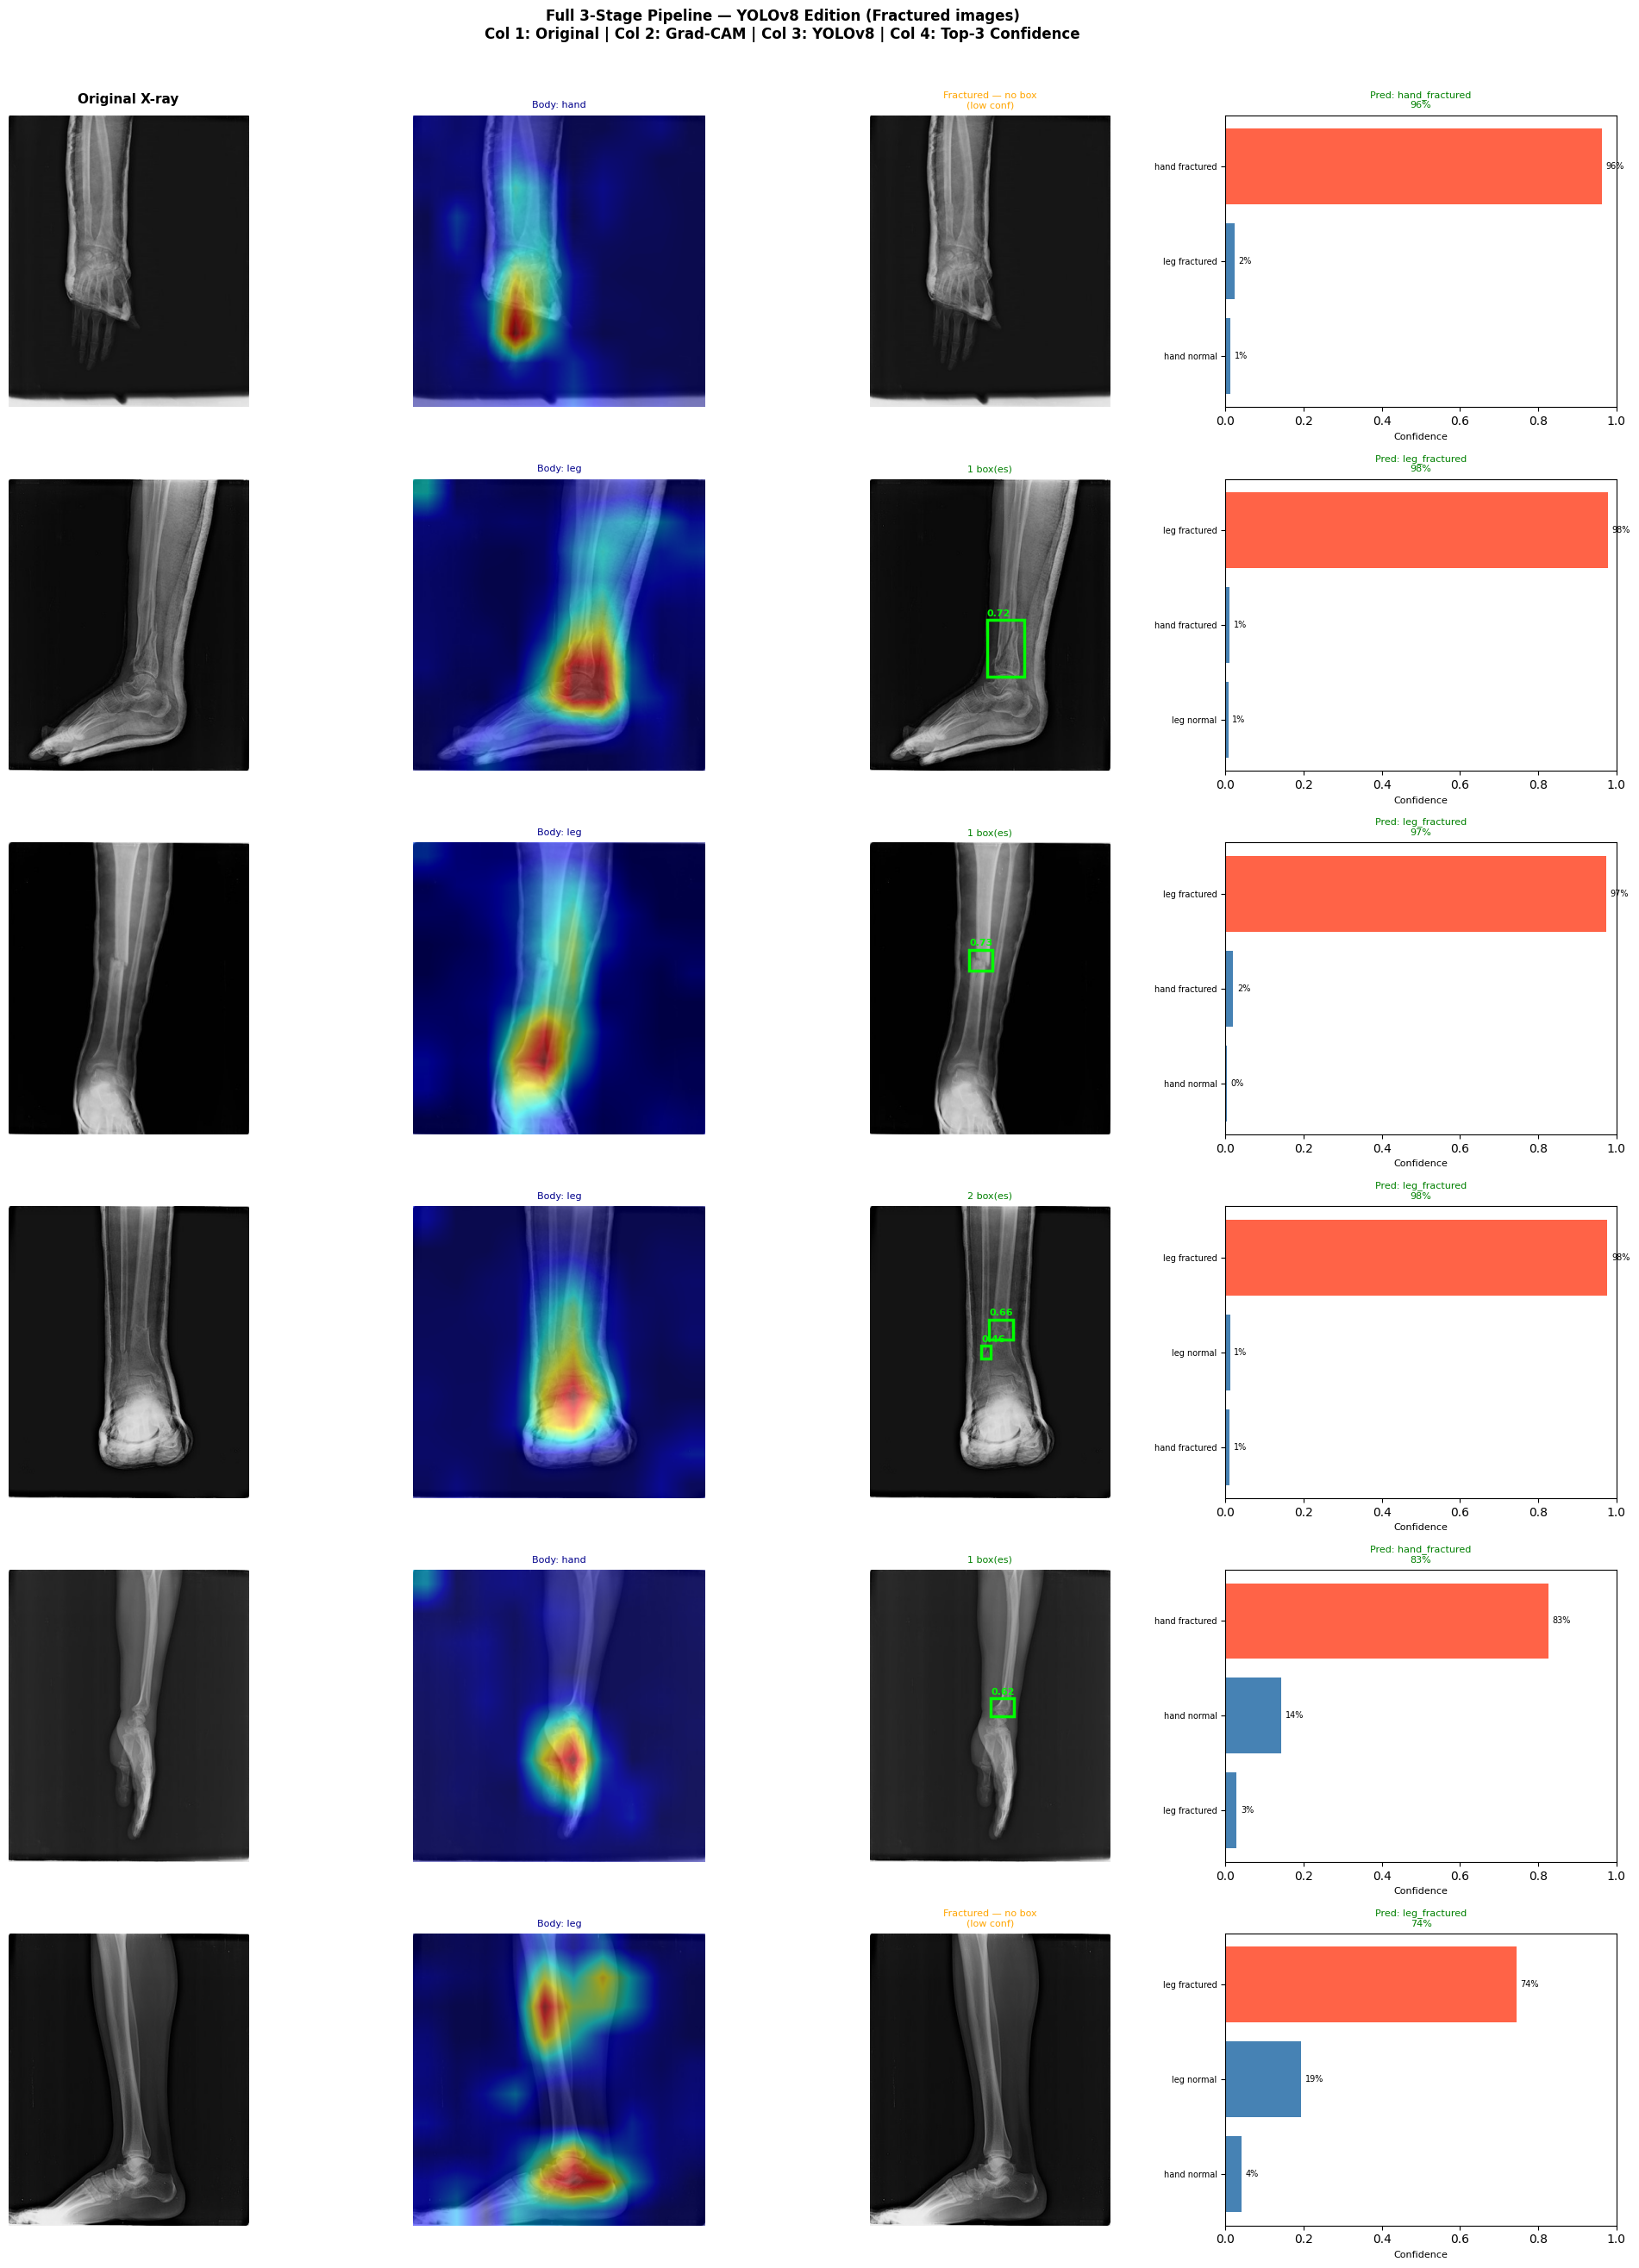

✅ Saved → yolo_full_pipeline.png


In [15]:
# ── Full pipeline — 6 fractured test images (YOLO) ───────────────
fractured_clf = [p for p in CLF_TEST_DIR.rglob('*.jpg')
                 if 'fractured' in p.parent.name]
random.shuffle(fractured_clf)
selected_yolo = fractured_clf[:6]

fig, axes = plt.subplots(6, 4, figsize=(20, 26))
col_titles = ['Original X-ray','Grad-CAM Attention','YOLOv8 Detection','Confidence Scores']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)

for row_idx, img_path in enumerate(selected_yolo):
    result = run_full_pipeline(
        img_path, clf_model, det_model, eval_transform,
        IDX_TO_CLASS, DEVICE, cam, IMG_SIZE,
        YOLO_IMG_SIZE, CONF_THRESH, IOU_THRESH,
        IMAGENET_MEAN, IMAGENET_STD, best_thresholds=best_thresholds)
    true_class  = img_path.parent.name
    is_correct  = result['pred_label'] == true_class
    title_color = 'green' if is_correct else 'red'

    axes[row_idx,0].imshow(result['pil_img'])
    axes[row_idx,0].set_ylabel(f'True: {true_class}', fontsize=8, rotation=0, ha='right')
    axes[row_idx,0].axis('off')

    axes[row_idx,1].imshow(result['cam_image'])
    axes[row_idx,1].set_title(f'Body: {result["body_part"]}', fontsize=8, color='darkblue')
    axes[row_idx,1].axis('off')

    axes[row_idx,2].imshow(result['pil_img'])
    if result['is_fractured'] and result['yolo_boxes']:
        for (x1,y1,x2,y2,cs) in result['yolo_boxes']:
            axes[row_idx,2].add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,
                linewidth=2.5, edgecolor='lime', facecolor='none'))
            axes[row_idx,2].text(x1,y1-6,f'{cs:.2f}',color='lime',fontsize=8,fontweight='bold')
        axes[row_idx,2].set_title(f'{len(result["yolo_boxes"])} box(es)',fontsize=8,color='green')
    elif result['is_fractured']:
        axes[row_idx,2].set_title('Fractured — no box\n(low conf)',fontsize=8,color='orange')
    else:
        axes[row_idx,2].set_title('Normal — no YOLO',fontsize=8,color='green')
    axes[row_idx,2].axis('off')

    ax_bar = axes[row_idx,3]
    labels = [t[0].replace('_',' ') for t in result['top3']]
    scores = [t[1] for t in result['top3']]
    colors_ = ['tomato' if j==0 else 'steelblue' for j in range(3)]
    ax_bar.barh(labels[::-1], scores[::-1], color=colors_[::-1])
    ax_bar.set_xlim(0,1); ax_bar.set_xlabel('Confidence',fontsize=8)
    ax_bar.set_title(f'Pred: {result["pred_label"][:15]}\n{result["confidence"]:.0%}',
                      fontsize=8, color=title_color)
    for j,(s,l) in enumerate(zip(scores[::-1],labels[::-1])):
        ax_bar.text(s+0.01,j,f'{s:.0%}',va='center',fontsize=7)
    ax_bar.tick_params(axis='y',labelsize=7)

plt.suptitle('Full 3-Stage Pipeline — YOLOv8 Edition (Fractured images)\n'
             'Col 1: Original | Col 2: Grad-CAM | Col 3: YOLOv8 | Col 4: Top-3 Confidence',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FINAL_FIG_DIR/'yolo_full_pipeline.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Saved → yolo_full_pipeline.png')


### Step 5.6 — YOLOv8 Missed Detections (Failure Cases)

YOLOv8 missed: 23 / 67 fractured images


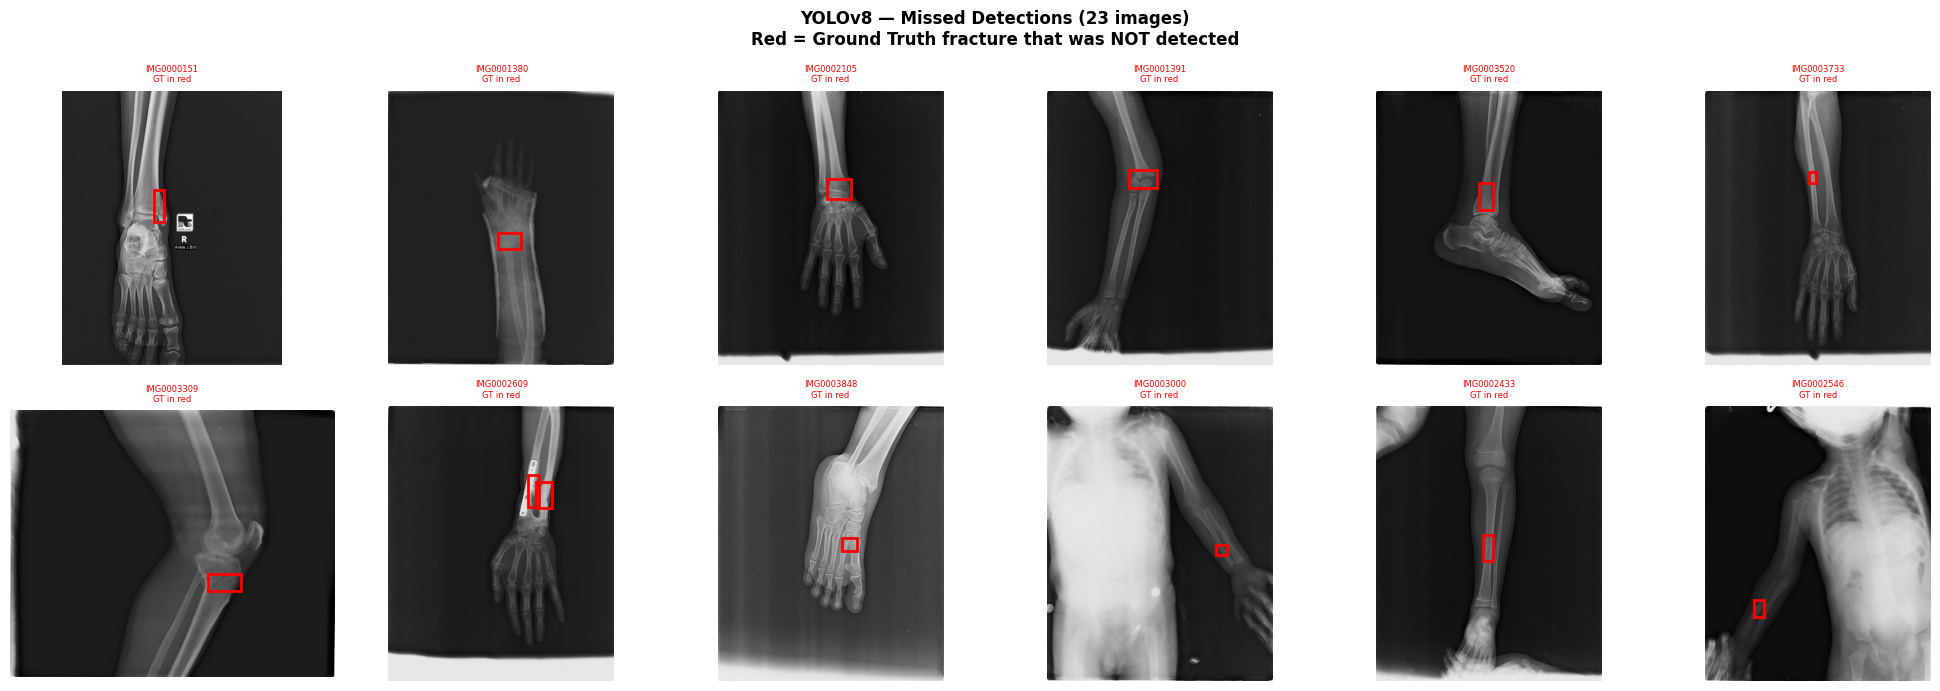

✅ Saved → yolo_missed_detections.png


In [16]:
# ── YOLOv8 missed detections — fractured test images ─────────────
yolo_misses = []
fractured_test_det = [
    p for p in test_det_imgs
    if (TEST_LBL_DIR/(p.stem+'.txt')).exists()
    and (TEST_LBL_DIR/(p.stem+'.txt')).stat().st_size > 0
]

for img_path in fractured_test_det:
    preds = det_model.predict(str(img_path), conf=CONF_THRESH,
                               iou=IOU_THRESH, imgsz=YOLO_IMG_SIZE, verbose=False)
    if len(preds[0].boxes) == 0:
        yolo_misses.append(img_path)

print(f'YOLOv8 missed: {len(yolo_misses)} / {len(fractured_test_det)} fractured images')

n_show = min(12, len(yolo_misses))
if n_show == 0:
    print('✅ YOLOv8 found at least one box in every fractured test image!')
else:
    fig, axes = plt.subplots(2, 6, figsize=(20, 7))
    for i, ax in enumerate(axes.flatten()):
        if i < n_show:
            img_path = yolo_misses[i]
            lbl_path = TEST_LBL_DIR / (img_path.stem+'.txt')
            img = Image.open(img_path).convert('RGB')
            W,H = img.size
            ax.imshow(img)
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts)==5:
                        _,xc,yc,bw,bh = map(float,parts)
                        ax.add_patch(patches.Rectangle(
                            ((xc-bw/2)*W,(yc-bh/2)*H),bw*W,bh*H,
                            linewidth=2,edgecolor='red',facecolor='none'))
            ax.set_title(f'{img_path.stem[:14]}\nGT in red',fontsize=6,color='red')
        ax.axis('off')
    plt.suptitle(f'YOLOv8 — Missed Detections ({len(yolo_misses)} images)\n'
                 'Red = Ground Truth fracture that was NOT detected',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FINAL_FIG_DIR/'yolo_missed_detections.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('✅ Saved → yolo_missed_detections.png')


### Step 5.7 — Demo: Single Image (YOLOv8)

Running full pipeline on: /content/drive/MyDrive/CV_project_v4/classification_dataset/test/hand_fractured/IMG0001362.jpg
True class: hand_fractured


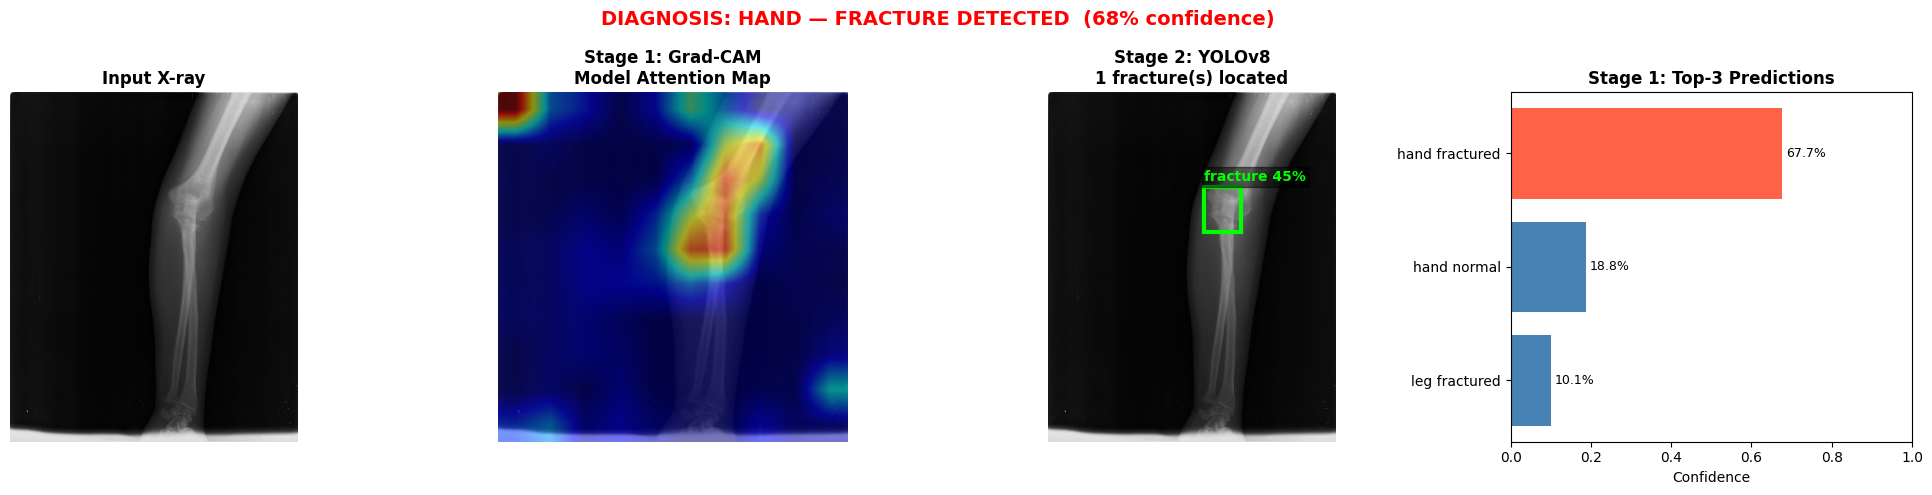


Pipeline output:
  Predicted:   hand_fractured  (67.7%)
  Fractured:   True
  YOLO boxes:  1

✅ Saved → yolo_demo.png


In [17]:
# ── CHANGE THIS to any X-ray image you want to demo ──────────────
# Using first test image by default
DEMO_IMAGE_PATH = list(CLF_TEST_DIR.rglob('*.jpg'))[0]
# DEMO_IMAGE_PATH = Path('/content/drive/MyDrive/my_xray.jpg')  # custom image

print(f'Running full pipeline on: {DEMO_IMAGE_PATH}')
print(f'True class: {DEMO_IMAGE_PATH.parent.name}')

result = run_full_pipeline(
    DEMO_IMAGE_PATH, clf_model, det_model, eval_transform,
    IDX_TO_CLASS, DEVICE, cam, IMG_SIZE,
    YOLO_IMG_SIZE, CONF_THRESH, IOU_THRESH,
    IMAGENET_MEAN, IMAGENET_STD,
    best_thresholds=best_thresholds
)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Panel 1: Original
axes[0].imshow(result['pil_img'])
axes[0].set_title('Input X-ray', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Panel 2: Grad-CAM
axes[1].imshow(result['cam_image'])
axes[1].set_title('Stage 1: Grad-CAM\nModel Attention Map', fontsize=12, fontweight='bold')
axes[1].axis('off')

# Panel 3: YOLO
axes[2].imshow(result['pil_img'])
if result['yolo_boxes']:
    for (x1,y1,x2,y2,conf_s) in result['yolo_boxes']:
        axes[2].add_patch(patches.Rectangle(
            (x1,y1), x2-x1, y2-y1,
            linewidth=3, edgecolor='lime', facecolor='none'
        ))
        axes[2].text(x1, y1-8, f'fracture {conf_s:.0%}',
                     color='lime', fontsize=10, fontweight='bold',
                     bbox=dict(facecolor='black', alpha=0.5, pad=2))
status = f'{len(result["yolo_boxes"])} fracture(s) located' if result['yolo_boxes'] \
         else ('No YOLO — normal' if not result['is_fractured'] else 'Fractured but no box')
axes[2].set_title(f'Stage 2: YOLOv8\n{status}', fontsize=12, fontweight='bold')
axes[2].axis('off')

# Panel 4: Top-3 bar chart
labels  = [t[0].replace('_',' ') for t in result['top3']]
scores  = [t[1] for t in result['top3']]
cols    = ['tomato','steelblue','steelblue']
axes[3].barh(labels[::-1], scores[::-1], color=cols[::-1])
axes[3].set_xlim(0, 1)
axes[3].set_xlabel('Confidence', fontsize=10)
axes[3].set_title('Stage 1: Top-3 Predictions', fontsize=12, fontweight='bold')
for j,(s,l) in enumerate(zip(scores[::-1],labels[::-1])):
    axes[3].text(s+0.01, j, f'{s:.1%}', va='center', fontsize=9)

# Final diagnosis title
diagnosis = f'DIAGNOSIS: {result["body_part"].upper()} — {"FRACTURE DETECTED" if result["is_fractured"] else "NORMAL"}  ({result["confidence"]:.0%} confidence)'
fig.suptitle(diagnosis, fontsize=14, fontweight='bold',
             color='red' if result['is_fractured'] else 'green')
plt.tight_layout()
plt.savefig(FINAL_FIG_DIR/'yolo_demo.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\nPipeline output:')
print(f'  Predicted:   {result["pred_label"]}  ({result["confidence"]:.1%})')
print(f'  Fractured:   {result["is_fractured"]}')
print(f'  YOLO boxes:  {len(result["yolo_boxes"])}')
print(f'\n✅ Saved → yolo_demo.png')

---
## 🔬 Section 6 — Faster R-CNN: Full Evaluation

**Exact same steps as Section 5 but for Faster R-CNN.**
Same filtered test set (hand + leg only), same validation images, same metrics.

| Step | Content | Saved as |
|---|---|---|
| 6.1 | Download & load Faster R-CNN | — |
| 6.2 | Run inference on filtered test set | — |
| 6.3 | Ground truth boxes (val) | `frcnn_gt_boxes.png` |
| 6.4 | Faster R-CNN predictions (val) | `frcnn_val_predictions.png` |
| 6.5 | Full 3-stage pipeline visualization | `frcnn_full_pipeline.png` |
| 6.6 | Missed detections | `frcnn_missed_detections.png` |
| 6.7 | Demo single image | `frcnn_demo.png` |


### Step 6.1 — Download & Load Faster R-CNN

In [18]:
# ── Download Faster R-CNN weights from Google Drive ──────────────
import subprocess
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

FRCNN_PATH = PROJECT_ROOT / 'best_fasterrcnn_fracture.pth'

if not FRCNN_PATH.exists():
    print('Downloading Faster R-CNN weights from Google Drive...')
    file_id = '1Ny2Poq4jp51BC7QzFagzvL-CTwfTtiXx'
    subprocess.run([
        'gdown', f'https://drive.google.com/uc?id={file_id}',
        '-O', str(FRCNN_PATH)
    ])
    print(f'✅ Downloaded to {FRCNN_PATH}')
else:
    print(f'✅ Faster R-CNN weights already on Drive: {FRCNN_PATH}')

print(f'   File size: {FRCNN_PATH.stat().st_size / 1e6:.1f} MB')


✅ Downloaded to /content/drive/MyDrive/CV_project_v4/best_fasterrcnn_fracture.pth
   File size: 165.7 MB


In [19]:
# ── Load Faster R-CNN ────────────────────────────────────────────
# Architecture: ResNet50 FPN backbone, 2 classes (background + fracture)
# Loading code provided by teammate

def load_faster_rcnn(weights_path, device):
    # 2 classes: background (0) + fracture (1)
    model = fasterrcnn_resnet50_fpn(weights=None)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, 2)
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.to(device)
    model.eval()
    return model

frcnn_model  = load_faster_rcnn(FRCNN_PATH, DEVICE)
total_params = sum(p.numel() for p in frcnn_model.parameters())
print(f'✅ Faster R-CNN loaded successfully')
print(f'   Backbone:   ResNet50 FPN')
print(f'   Classes:    2 (background + fracture)')
print(f'   Parameters: {total_params:,}')
print(f'   Device:     {DEVICE}')


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 198MB/s]


✅ Faster R-CNN loaded successfully
   Backbone:   ResNet50 FPN
   Classes:    2 (background + fracture)
   Parameters: 41,299,161
   Device:     cuda


### Step 6.2 — Run Faster R-CNN on Filtered Test Set (Hand + Leg Only)

In [20]:
import time as time_mod
from torchvision import transforms as T

frcnn_transform = T.Compose([T.ToTensor()])

def run_frcnn_on_image(img_path, frcnn_model, device, conf_thresh=0.5):
    pil_img = Image.open(img_path).convert('RGB')
    tensor  = frcnn_transform(pil_img).unsqueeze(0).to(device)
    with torch.no_grad():
        preds = frcnn_model(tensor)
    result_boxes = []
    for box, score, label in zip(preds[0]['boxes'].cpu().numpy(),
                                  preds[0]['scores'].cpu().numpy(),
                                  preds[0]['labels'].cpu().numpy()):
        if label == 1 and score >= conf_thresh:
            result_boxes.append((float(box[0]),float(box[1]),
                                  float(box[2]),float(box[3]),float(score)))
    return result_boxes, pil_img

FRCNN_CONF    = 0.5
frcnn_results = {}
frcnn_times   = []

print(f'Running Faster R-CNN on {len(test_det_imgs)} hand+leg test images...')
for i, img_path in enumerate(test_det_imgs):
    t0 = time_mod.time()
    boxes, _ = run_frcnn_on_image(img_path, frcnn_model, DEVICE, FRCNN_CONF)
    frcnn_times.append((time_mod.time()-t0)*1000)
    frcnn_results[img_path.stem] = boxes
    if (i+1) % 20 == 0:
        print(f'  {i+1}/{len(test_det_imgs)} done...')

avg_frcnn_time = float(np.mean(frcnn_times))
print(f'\n✅ Done. Avg inference: {avg_frcnn_time:.1f} ms/image')
print(f'   Images with detections: {sum(1 for v in frcnn_results.values() if v)}')


Running Faster R-CNN on 135 hand+leg test images...
  20/135 done...
  40/135 done...
  60/135 done...
  80/135 done...
  100/135 done...
  120/135 done...

✅ Done. Avg inference: 126.1 ms/image
   Images with detections: 51


### Step 6.3 — Ground Truth Bounding Boxes (Validation Set)

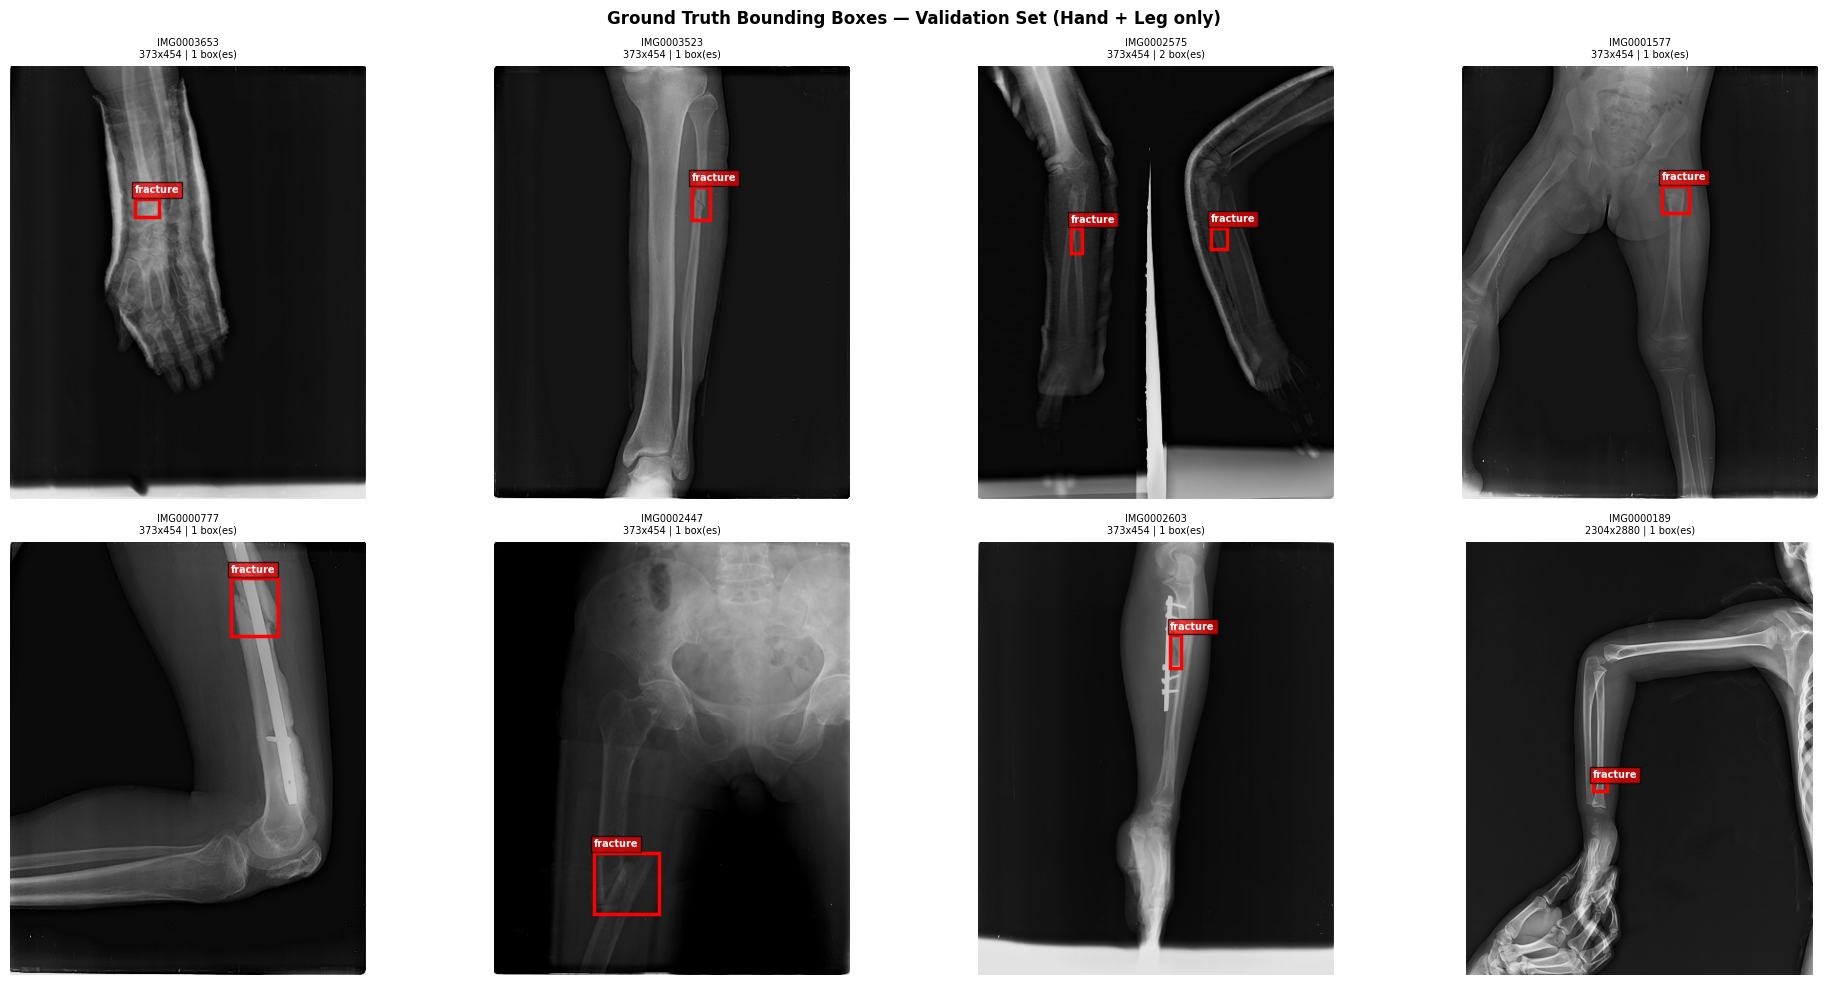

✅ Saved → frcnn_gt_boxes.png


In [21]:
# Same GT boxes as Step 5.3 — shared annotation for both models
pos_val_frcnn = [
    img for img in val_det_imgs
    if (VAL_LBL_DIR/(img.stem+'.txt')).exists()
    and (VAL_LBL_DIR/(img.stem+'.txt')).stat().st_size > 0
]
random.shuffle(pos_val_frcnn)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, ax in enumerate(axes[:min(8, len(pos_val_frcnn))]):
    img_path = pos_val_frcnn[i]
    lbl_path = VAL_LBL_DIR / (img_path.stem+'.txt')
    img = Image.open(img_path).convert('RGB')
    W,H = img.size
    ax.imshow(img)
    n_boxes = 0
    with open(lbl_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts)==5:
                _,xc,yc,bw,bh = map(float,parts)
                x1=(xc-bw/2)*W; y1=(yc-bh/2)*H
                ax.add_patch(patches.Rectangle((x1,y1),bw*W,bh*H,
                    linewidth=2.5, edgecolor='red', facecolor='none'))
                ax.text(x1,y1-6,'fracture',color='white',fontsize=7,
                        fontweight='bold',bbox=dict(facecolor='red',alpha=0.7,pad=2))
                n_boxes += 1
    ax.set_title(f'{img_path.stem[:15]}\n{W}x{H} | {n_boxes} box(es)', fontsize=7)
    ax.axis('off')

plt.suptitle('Ground Truth Bounding Boxes — Validation Set (Hand + Leg only)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FINAL_FIG_DIR/'frcnn_gt_boxes.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Saved → frcnn_gt_boxes.png')


### Step 6.4 — Faster R-CNN Predictions vs Ground Truth (Validation Set)

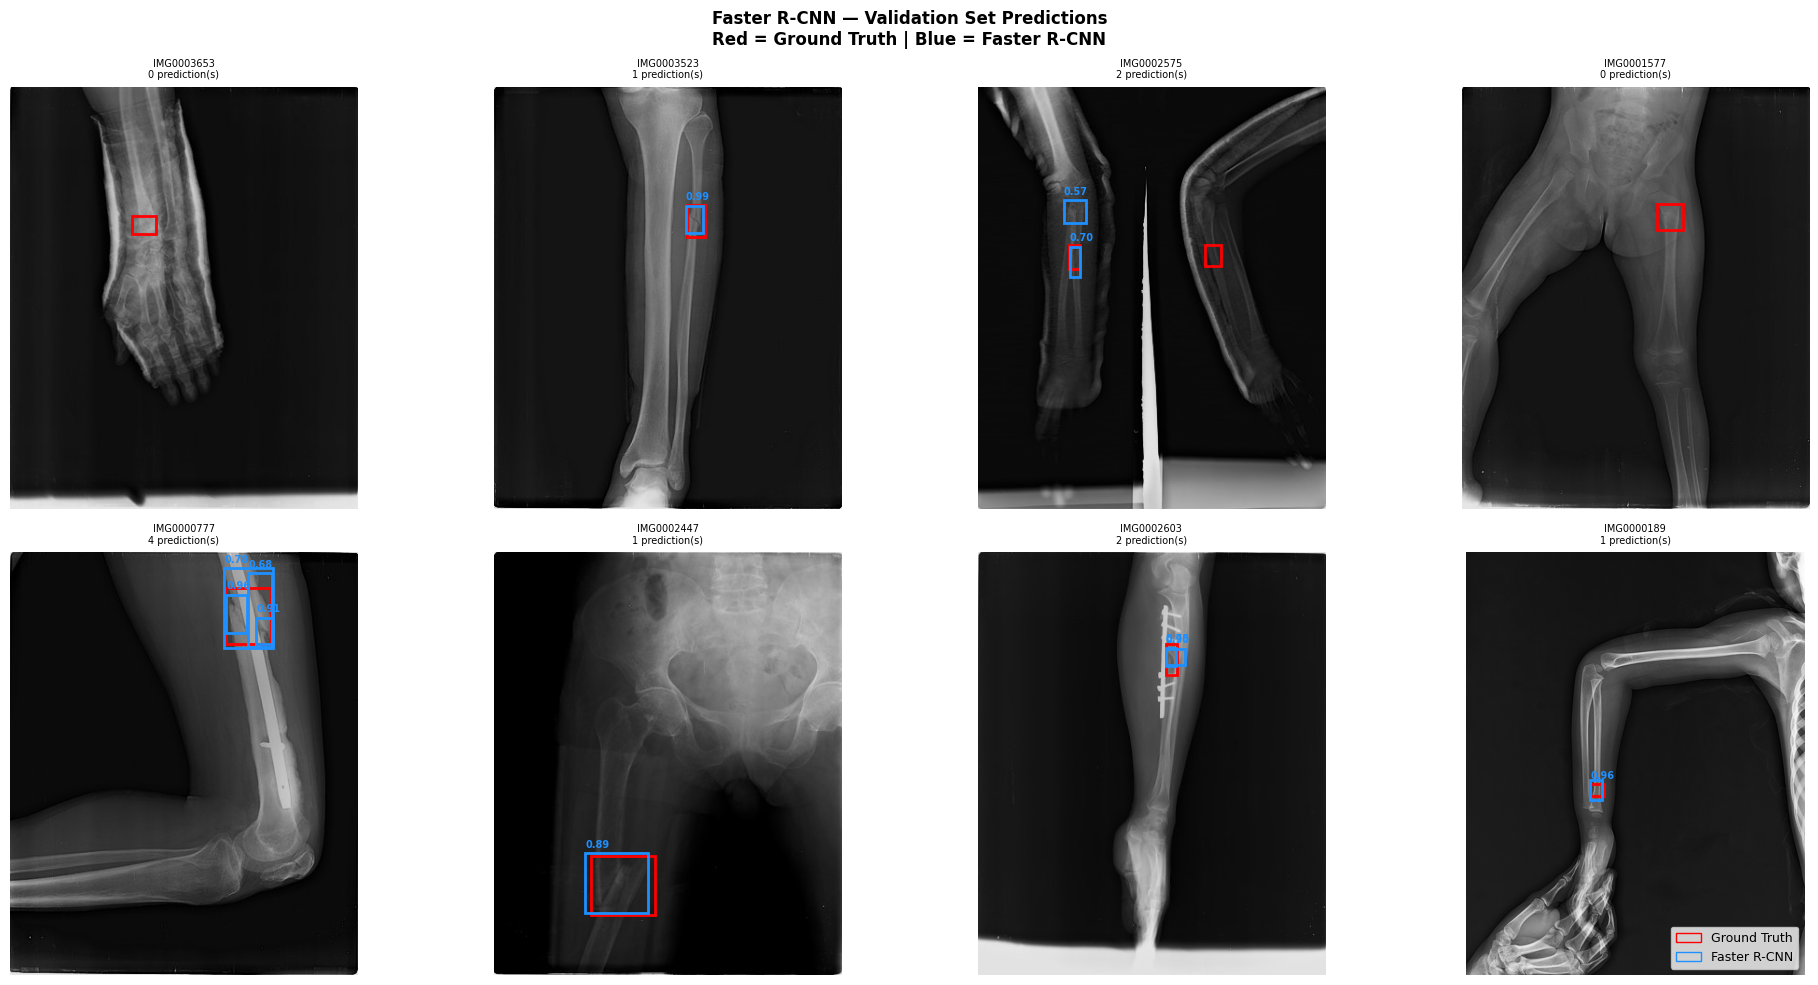

✅ Saved → frcnn_val_predictions.png


In [22]:
# ── Faster R-CNN predictions vs GT — val set ─────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, ax in enumerate(axes[:min(8, len(pos_val_frcnn))]):
    img_path = pos_val_frcnn[i]
    lbl_path = VAL_LBL_DIR / (img_path.stem+'.txt')
    img = Image.open(img_path).convert('RGB')
    W,H = img.size
    ax.imshow(img)
    # GT (red)
    with open(lbl_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts)==5:
                _,xc,yc,bw,bh = map(float,parts)
                x1=(xc-bw/2)*W; y1=(yc-bh/2)*H
                ax.add_patch(patches.Rectangle((x1,y1),bw*W,bh*H,
                    linewidth=2, edgecolor='red', facecolor='none'))
    # FRCNN (blue)
    frcnn_val_boxes, _ = run_frcnn_on_image(img_path, frcnn_model, DEVICE, FRCNN_CONF)
    n_pred = 0
    for (x1,y1,x2,y2,score) in frcnn_val_boxes:
        ax.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,
            linewidth=2, edgecolor='dodgerblue', facecolor='none'))
        ax.text(x1,y1-6,f'{score:.2f}',color='dodgerblue',fontsize=7,fontweight='bold')
        n_pred += 1
    ax.set_title(f'{img_path.stem[:15]}\n{n_pred} prediction(s)', fontsize=7)
    ax.axis('off')

from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(facecolor='none',edgecolor='red',        label='Ground Truth'),
    Patch(facecolor='none',edgecolor='dodgerblue', label='Faster R-CNN'),
], loc='lower right', fontsize=9)
plt.suptitle('Faster R-CNN — Validation Set Predictions\nRed = Ground Truth | Blue = Faster R-CNN',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FINAL_FIG_DIR/'frcnn_val_predictions.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Saved → frcnn_val_predictions.png')


### Step 6.5 — Full 3-Stage Pipeline Visualization (Faster R-CNN)

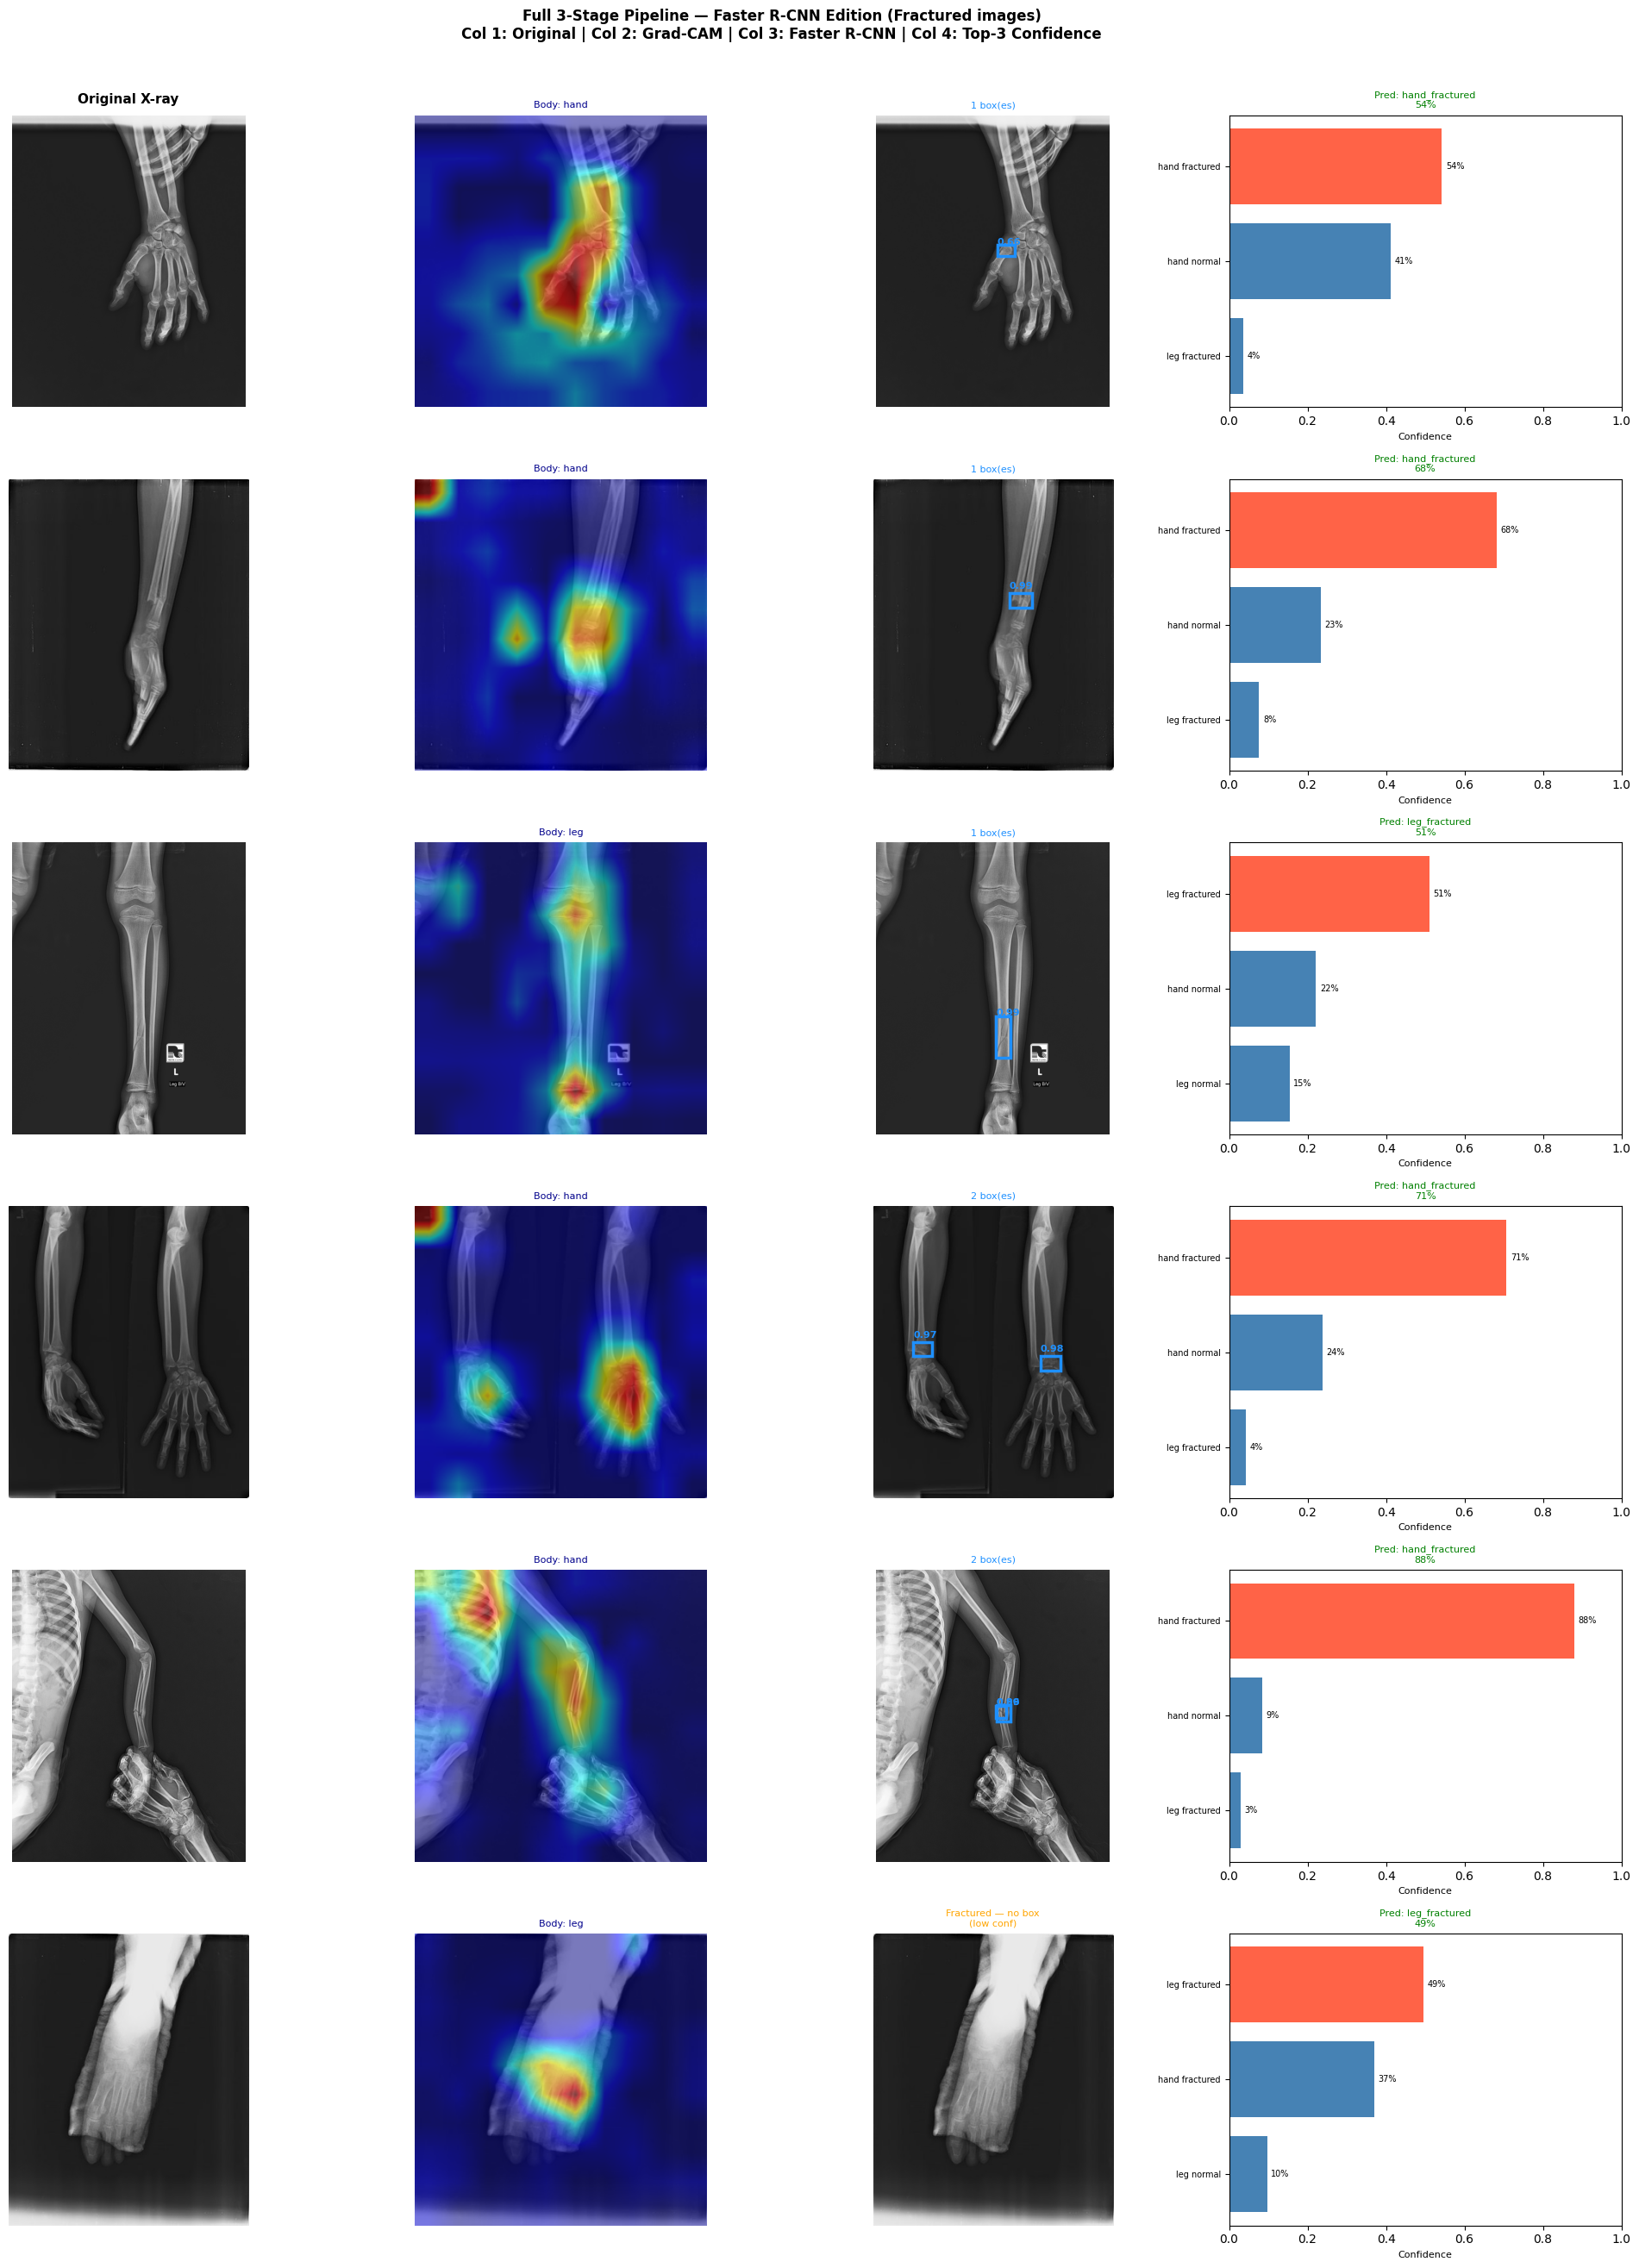

✅ Saved → frcnn_full_pipeline.png


In [23]:
# ── Full pipeline — 6 fractured test images (FRCNN) ─────────────
random.shuffle(fractured_clf)
selected_frcnn = fractured_clf[:6]

fig, axes = plt.subplots(6, 4, figsize=(20, 26))
col_titles = ['Original X-ray','Grad-CAM Attention','Faster R-CNN Detection','Confidence Scores']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)

for row_idx, img_path in enumerate(selected_frcnn):
    result = run_full_pipeline(
        img_path, clf_model, det_model, eval_transform,
        IDX_TO_CLASS, DEVICE, cam, IMG_SIZE,
        YOLO_IMG_SIZE, CONF_THRESH, IOU_THRESH,
        IMAGENET_MEAN, IMAGENET_STD, best_thresholds=best_thresholds)
    true_class  = img_path.parent.name
    is_correct  = result['pred_label'] == true_class
    title_color = 'green' if is_correct else 'red'

    axes[row_idx,0].imshow(result['pil_img'])
    axes[row_idx,0].set_ylabel(f'True: {true_class}', fontsize=8, rotation=0, ha='right')
    axes[row_idx,0].axis('off')

    axes[row_idx,1].imshow(result['cam_image'])
    axes[row_idx,1].set_title(f'Body: {result["body_part"]}', fontsize=8, color='darkblue')
    axes[row_idx,1].axis('off')

    # FRCNN boxes instead of YOLO
    axes[row_idx,2].imshow(result['pil_img'])
    if result['is_fractured']:
        frcnn_pipeline_boxes, _ = run_frcnn_on_image(img_path, frcnn_model, DEVICE, FRCNN_CONF)
        if frcnn_pipeline_boxes:
            for (x1,y1,x2,y2,sc) in frcnn_pipeline_boxes:
                axes[row_idx,2].add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,
                    linewidth=2.5, edgecolor='dodgerblue', facecolor='none'))
                axes[row_idx,2].text(x1,y1-6,f'{sc:.2f}',color='dodgerblue',fontsize=8,fontweight='bold')
            axes[row_idx,2].set_title(f'{len(frcnn_pipeline_boxes)} box(es)',fontsize=8,color='dodgerblue')
        else:
            axes[row_idx,2].set_title('Fractured — no box\n(low conf)',fontsize=8,color='orange')
    else:
        axes[row_idx,2].set_title('Normal — FRCNN\nnot triggered',fontsize=8,color='green')
    axes[row_idx,2].axis('off')

    ax_bar = axes[row_idx,3]
    labels = [t[0].replace('_',' ') for t in result['top3']]
    scores = [t[1] for t in result['top3']]
    colors_ = ['tomato' if j==0 else 'steelblue' for j in range(3)]
    ax_bar.barh(labels[::-1], scores[::-1], color=colors_[::-1])
    ax_bar.set_xlim(0,1); ax_bar.set_xlabel('Confidence',fontsize=8)
    ax_bar.set_title(f'Pred: {result["pred_label"][:15]}\n{result["confidence"]:.0%}',
                      fontsize=8, color=title_color)
    for j,(s,l) in enumerate(zip(scores[::-1],labels[::-1])):
        ax_bar.text(s+0.01,j,f'{s:.0%}',va='center',fontsize=7)
    ax_bar.tick_params(axis='y',labelsize=7)

plt.suptitle('Full 3-Stage Pipeline — Faster R-CNN Edition (Fractured images)\n'
             'Col 1: Original | Col 2: Grad-CAM | Col 3: Faster R-CNN | Col 4: Top-3 Confidence',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FINAL_FIG_DIR/'frcnn_full_pipeline.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Saved → frcnn_full_pipeline.png')


### Step 6.6 — Faster R-CNN Missed Detections (Failure Cases)

Faster R-CNN missed: 18 / 67 fractured images


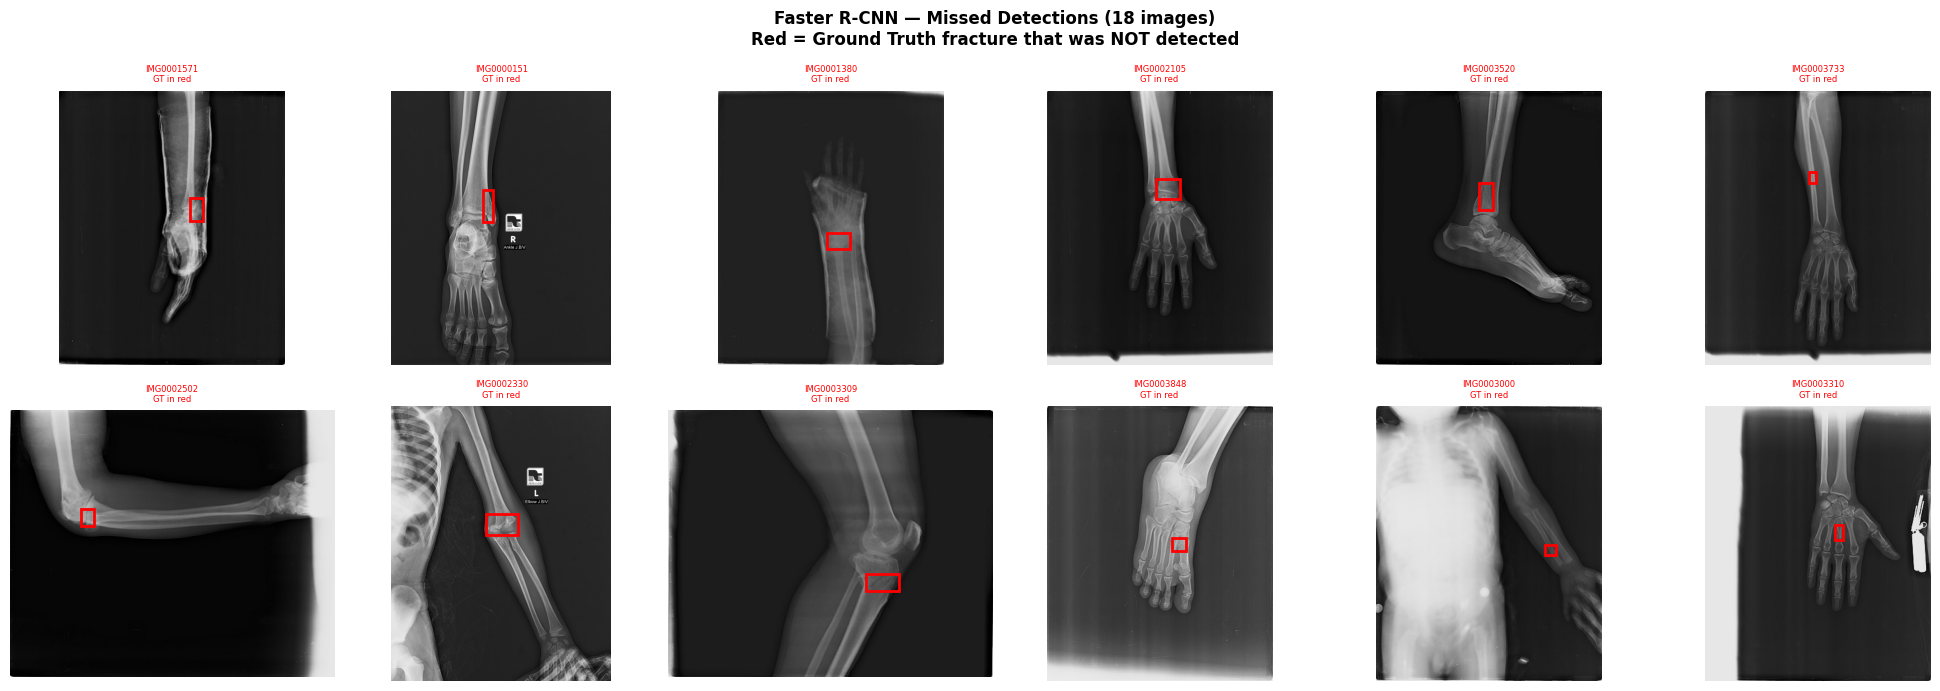

✅ Saved → frcnn_missed_detections.png


In [24]:
# ── FRCNN missed detections ──────────────────────────────────────
frcnn_misses = [
    p for p in fractured_test_det
    if not frcnn_results.get(p.stem, [])
]
print(f'Faster R-CNN missed: {len(frcnn_misses)} / {len(fractured_test_det)} fractured images')

n_show = min(12, len(frcnn_misses))
if n_show == 0:
    print('✅ Faster R-CNN found at least one box in every fractured test image!')
else:
    fig, axes = plt.subplots(2, 6, figsize=(20, 7))
    for i, ax in enumerate(axes.flatten()):
        if i < n_show:
            img_path = frcnn_misses[i]
            lbl_path = TEST_LBL_DIR / (img_path.stem+'.txt')
            img = Image.open(img_path).convert('RGB')
            W,H = img.size
            ax.imshow(img)
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts)==5:
                        _,xc,yc,bw,bh = map(float,parts)
                        ax.add_patch(patches.Rectangle(
                            ((xc-bw/2)*W,(yc-bh/2)*H),bw*W,bh*H,
                            linewidth=2,edgecolor='red',facecolor='none'))
            ax.set_title(f'{img_path.stem[:14]}\nGT in red',fontsize=6,color='red')
        ax.axis('off')
    plt.suptitle(f'Faster R-CNN — Missed Detections ({len(frcnn_misses)} images)\n'
                 'Red = Ground Truth fracture that was NOT detected',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FINAL_FIG_DIR/'frcnn_missed_detections.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('✅ Saved → frcnn_missed_detections.png')


### Step 6.7 — Demo: Single Image (Faster R-CNN)

Demo image: /content/drive/MyDrive/CV_project_v4/classification_dataset/test/hand_fractured/IMG0001362.jpg
True class: hand_fractured


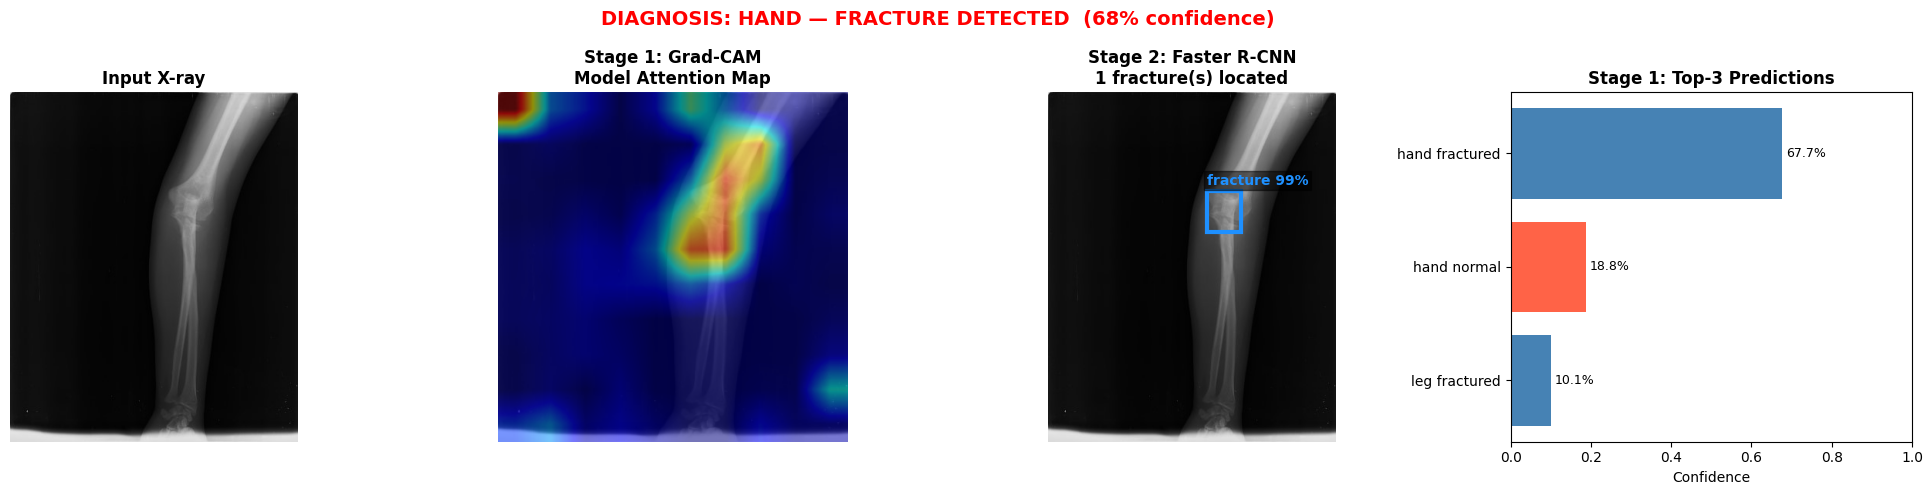


✅ Saved → frcnn_demo.png
  Predicted: hand_fractured  (67.7%)
  FRCNN boxes: 1


In [25]:
# ── Demo single image — Faster R-CNN version ─────────────────────
DEMO_IMAGE_PATH_FRCNN = list(CLF_TEST_DIR.rglob('*.jpg'))[0]
print(f'Demo image: {DEMO_IMAGE_PATH_FRCNN}')
print(f'True class: {DEMO_IMAGE_PATH_FRCNN.parent.name}')

result_frcnn = run_full_pipeline(
    DEMO_IMAGE_PATH_FRCNN, clf_model, det_model, eval_transform,
    IDX_TO_CLASS, DEVICE, cam, IMG_SIZE,
    YOLO_IMG_SIZE, CONF_THRESH, IOU_THRESH,
    IMAGENET_MEAN, IMAGENET_STD, best_thresholds=best_thresholds)

frcnn_demo_boxes, _ = run_frcnn_on_image(
    DEMO_IMAGE_PATH_FRCNN, frcnn_model, DEVICE, FRCNN_CONF)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(result_frcnn['pil_img'])
axes[0].set_title('Input X-ray', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(result_frcnn['cam_image'])
axes[1].set_title('Stage 1: Grad-CAM\nModel Attention Map', fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(result_frcnn['pil_img'])
if result_frcnn['is_fractured'] and frcnn_demo_boxes:
    for (x1,y1,x2,y2,sc) in frcnn_demo_boxes:
        axes[2].add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,
            linewidth=3, edgecolor='dodgerblue', facecolor='none'))
        axes[2].text(x1,y1-8,f'fracture {sc:.0%}',color='dodgerblue',fontsize=10,
                     fontweight='bold',bbox=dict(facecolor='black',alpha=0.5,pad=2))
    status_f = f'{len(frcnn_demo_boxes)} fracture(s) located'
elif result_frcnn['is_fractured']:
    status_f = 'Fractured but no box detected'
else:
    status_f = 'Normal — FRCNN not triggered'
axes[2].set_title(f'Stage 2: Faster R-CNN\n{status_f}', fontsize=12, fontweight='bold')
axes[2].axis('off')

labels = [t[0].replace('_',' ') for t in result_frcnn['top3']]
scores = [t[1] for t in result_frcnn['top3']]
axes[3].barh(labels[::-1], scores[::-1], color=['steelblue','tomato','steelblue'][::-1])
axes[3].set_xlim(0,1); axes[3].set_xlabel('Confidence',fontsize=10)
axes[3].set_title('Stage 1: Top-3 Predictions', fontsize=12, fontweight='bold')
for j,(s,l) in enumerate(zip(scores[::-1],labels[::-1])):
    axes[3].text(s+0.01,j,f'{s:.1%}',va='center',fontsize=9)

diag = (f'DIAGNOSIS: {result_frcnn["body_part"].upper()} — '
        f'{"FRACTURE DETECTED" if result_frcnn["is_fractured"] else "NORMAL"}'
        f'  ({result_frcnn["confidence"]:.0%} confidence)')
fig.suptitle(diag, fontsize=14, fontweight='bold',
             color='red' if result_frcnn['is_fractured'] else 'green')
plt.tight_layout()
plt.savefig(FINAL_FIG_DIR/'frcnn_demo.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'\n✅ Saved → frcnn_demo.png')
print(f'  Predicted: {result_frcnn["pred_label"]}  ({result_frcnn["confidence"]:.1%})')
print(f'  FRCNN boxes: {len(frcnn_demo_boxes)}')


---
## ⚖️ Section 7 — Model Comparison: YOLOv8 vs Faster R-CNN

All comparisons on the **same filtered test set** (hand + leg only).

| Step | Content | Saved as |
|---|---|---|
| 7.1 | Side-by-side visual (GT / YOLO / FRCNN) | `comparison_visual.png` |
| 7.2 | Quantitative metrics table | `comparison_metrics.csv` |
| 7.3 | Bar charts | `comparison_chart.png` |
| 7.4 | Scientific discussion | — |


### Step 7.1 — Side-by-Side Visual Comparison

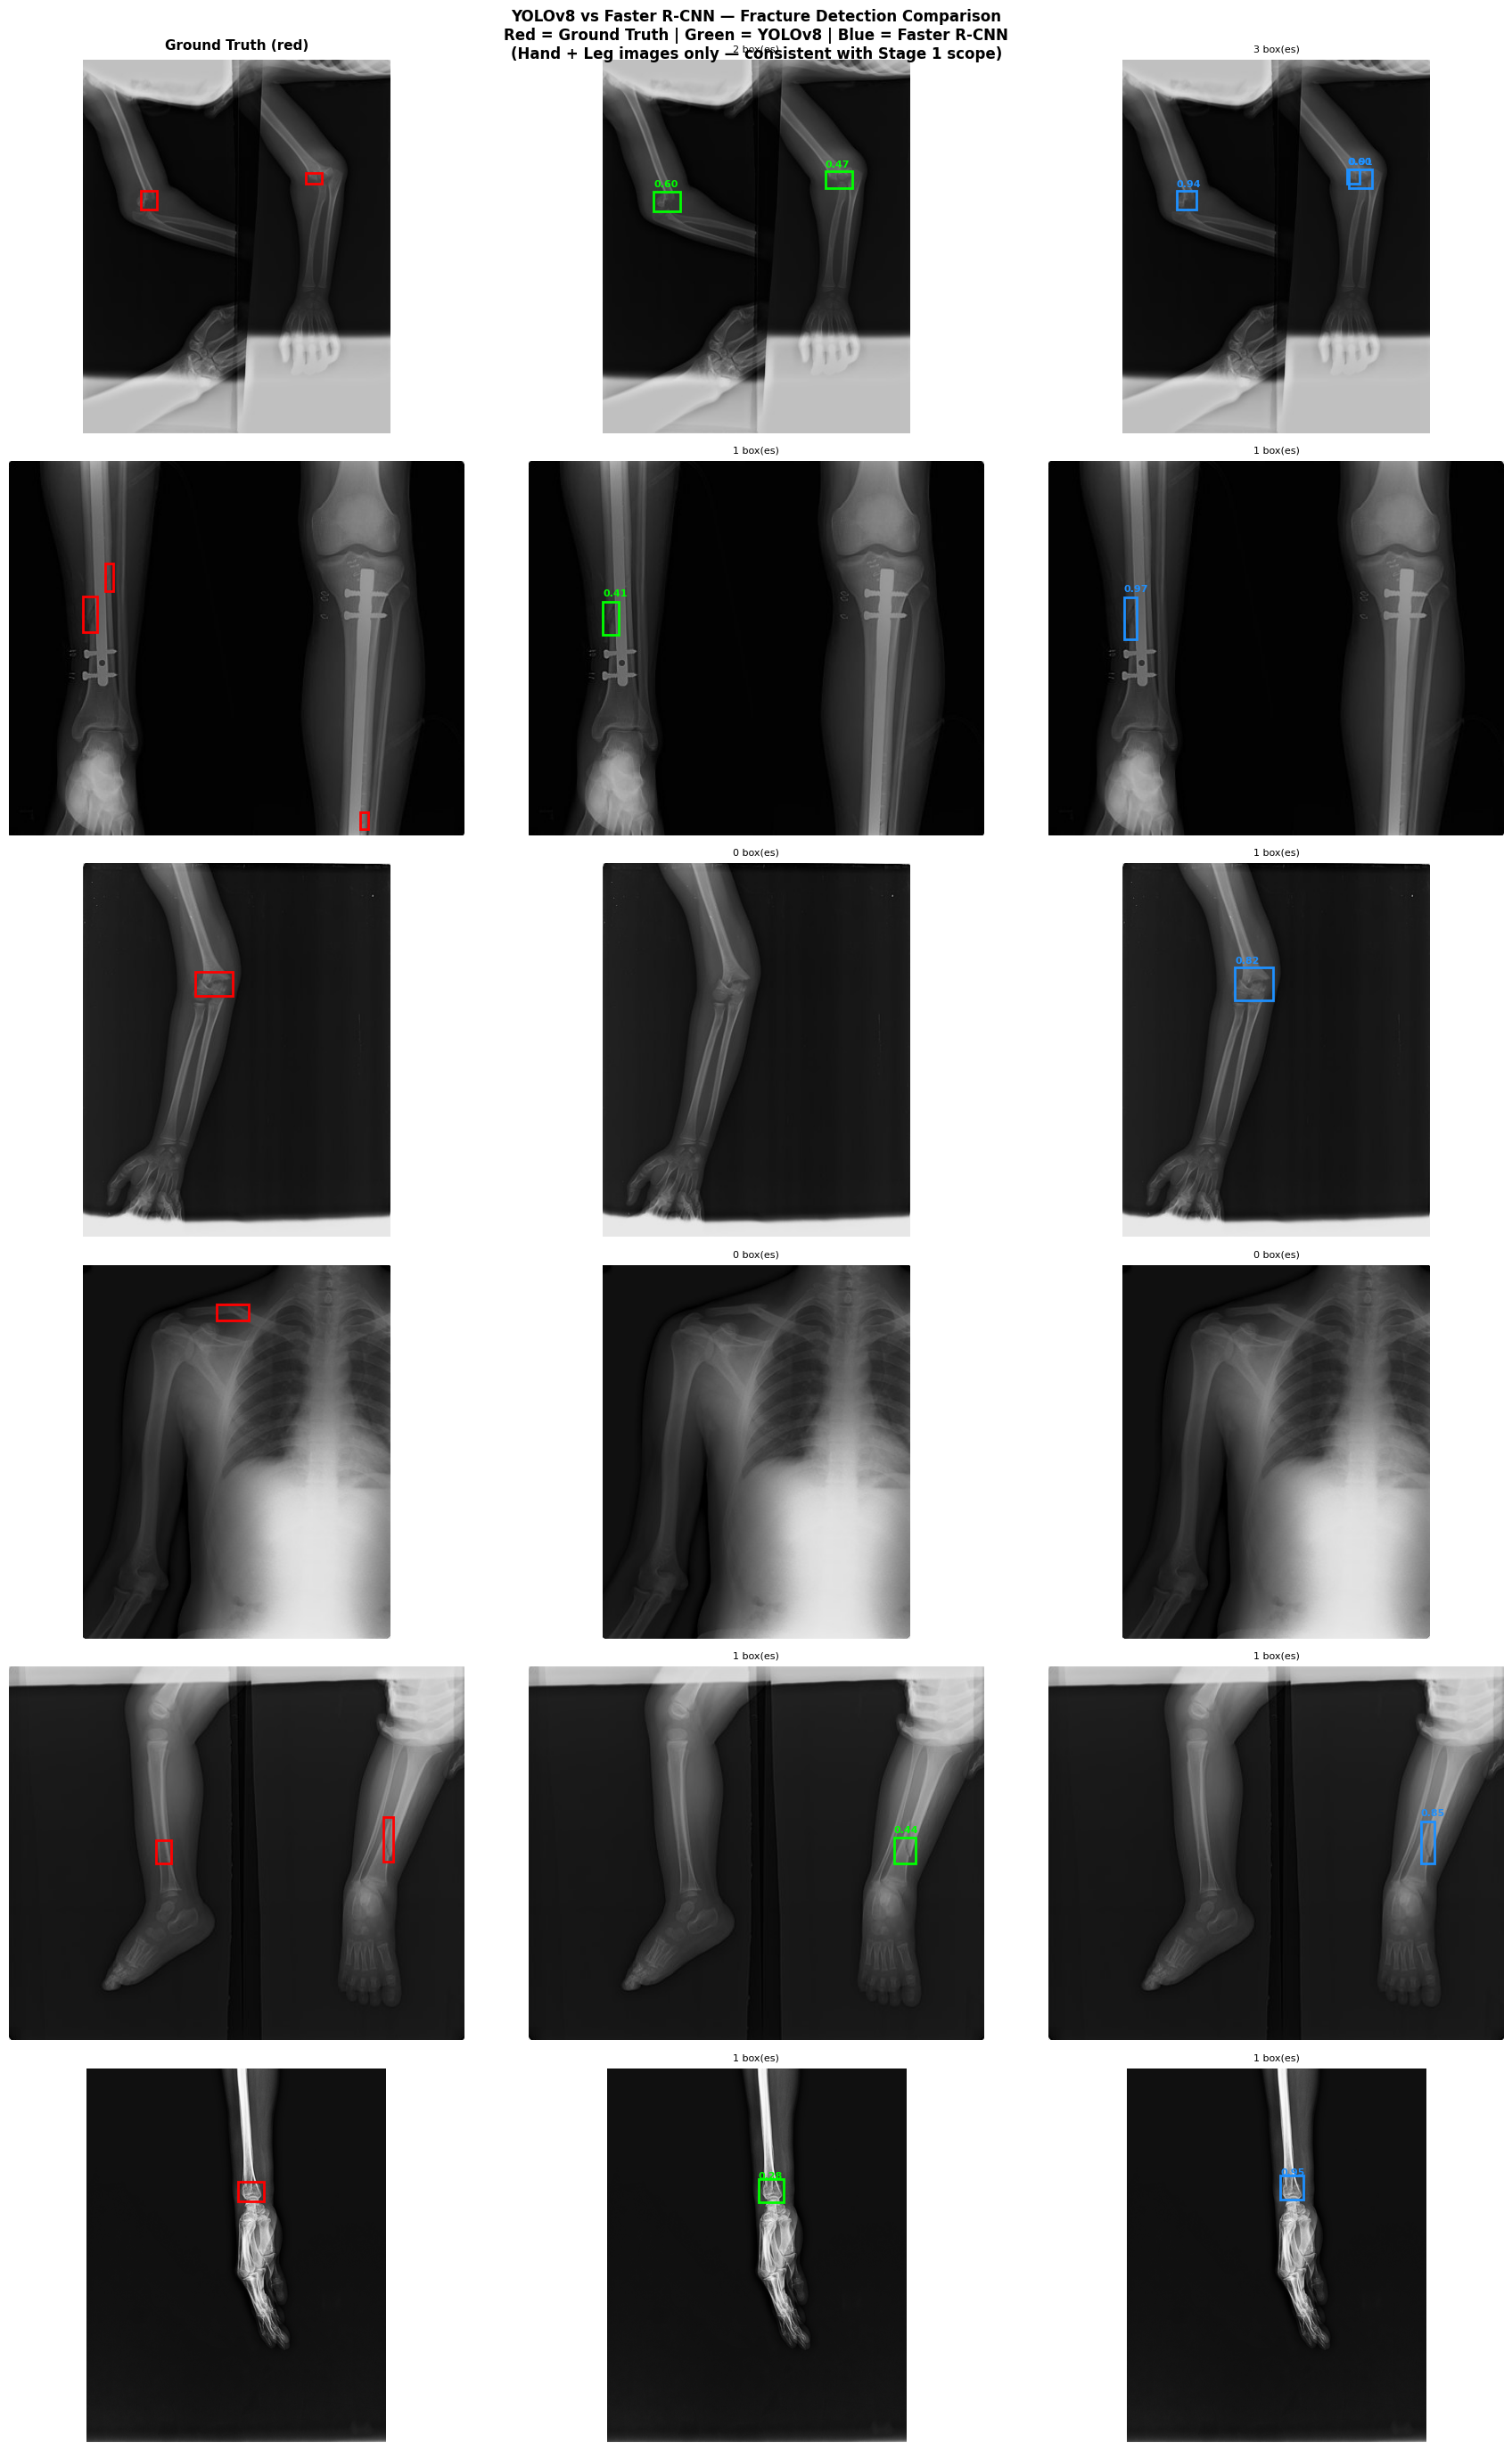

✅ Saved → comparison_visual.png


In [26]:
# ── 6 fractured test images: GT / YOLO / FRCNN ───────────────────
fractured_test_det = [
    p for p in test_det_imgs
    if (TEST_LBL_DIR/(p.stem+'.txt')).exists()
    and (TEST_LBL_DIR/(p.stem+'.txt')).stat().st_size > 0
]
random.shuffle(fractured_test_det)
compare_imgs = fractured_test_det[:6]

fig, axes = plt.subplots(6, 3, figsize=(18, 28))
for ax, title in zip(axes[0], [
    'Ground Truth (red)',
    'YOLOv8 Prediction (green)',
    'Faster R-CNN Prediction (blue)'
]):
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)

for row_idx, img_path in enumerate(compare_imgs):
    pil_img = Image.open(img_path).convert('RGB')
    W,H = pil_img.size
    lbl_path = TEST_LBL_DIR / (img_path.stem+'.txt')
    gt_boxes = []
    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts)==5:
                    _,xc,yc,bw,bh = map(float,parts)
                    gt_boxes.append(((xc-bw/2)*W,(yc-bh/2)*H,(xc+bw/2)*W,(yc+bh/2)*H))

    # Col 0: GT
    axes[row_idx,0].imshow(pil_img)
    for (x1,y1,x2,y2) in gt_boxes:
        axes[row_idx,0].add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,
            linewidth=2,edgecolor='red',facecolor='none'))
    axes[row_idx,0].set_ylabel(img_path.stem[:12],fontsize=7,rotation=0,ha='right')
    axes[row_idx,0].axis('off')

    # Col 1: YOLO
    yolo_p = det_model.predict(str(img_path),conf=CONF_THRESH,
                                iou=IOU_THRESH,imgsz=YOLO_IMG_SIZE,verbose=False)
    axes[row_idx,1].imshow(pil_img)
    n_y = 0
    for det in yolo_p[0].boxes:
        x1,y1,x2,y2 = det.xyxy[0].cpu().numpy()
        axes[row_idx,1].add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,
            linewidth=2,edgecolor='lime',facecolor='none'))
        axes[row_idx,1].text(x1,y1-5,f'{float(det.conf[0]):.2f}',
                              color='lime',fontsize=8,fontweight='bold')
        n_y += 1
    axes[row_idx,1].set_title(f'{n_y} box(es)',fontsize=8)
    axes[row_idx,1].axis('off')

    # Col 2: FRCNN
    frcnn_b, _ = run_frcnn_on_image(img_path,frcnn_model,DEVICE,FRCNN_CONF)
    axes[row_idx,2].imshow(pil_img)
    for (x1,y1,x2,y2,sc) in frcnn_b:
        axes[row_idx,2].add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,
            linewidth=2,edgecolor='dodgerblue',facecolor='none'))
        axes[row_idx,2].text(x1,y1-5,f'{sc:.2f}',
                              color='dodgerblue',fontsize=8,fontweight='bold')
    axes[row_idx,2].set_title(f'{len(frcnn_b)} box(es)',fontsize=8)
    axes[row_idx,2].axis('off')

plt.suptitle('YOLOv8 vs Faster R-CNN — Fracture Detection Comparison\n'
             'Red = Ground Truth | Green = YOLOv8 | Blue = Faster R-CNN\n'
             '(Hand + Leg images only — consistent with Stage 1 scope)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FINAL_FIG_DIR/'comparison_visual.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Saved → comparison_visual.png')


### Step 7.2 — Quantitative Metrics (IoU@0.5 on Hand+Leg Test Set)

In [27]:
def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0]); yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2]); yB = min(boxA[3], boxB[3])
    inter = max(0, xB-xA) * max(0, yB-yA)
    areaA = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])
    union = areaA + areaB - inter
    return inter / union if union > 0 else 0.0

tp_f = fp_f = fn_f = 0
tp_y = fp_y = fn_y = 0

for img_path in fractured_test_det:
    pil_img  = Image.open(img_path).convert('RGB')
    W, H     = pil_img.size
    lbl_path = TEST_LBL_DIR / (img_path.stem + '.txt')
    gt_boxes = []
    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    _, xc, yc, bw, bh = map(float, parts)
                    gt_boxes.append([(xc-bw/2)*W,(yc-bh/2)*H,
                                     (xc+bw/2)*W,(yc+bh/2)*H])
    if not gt_boxes:
        continue

    # Faster R-CNN
    frc_preds = frcnn_results.get(img_path.stem, [])
    matched   = set()
    for (x1,y1,x2,y2,sc) in frc_preds:
        ok = False
        for gi, gt in enumerate(gt_boxes):
            if gi not in matched and compute_iou([x1,y1,x2,y2], gt) > 0.5:
                tp_f += 1; matched.add(gi); ok = True; break
        if not ok: fp_f += 1
    fn_f += len(gt_boxes) - len(matched)

    # YOLOv8
    yp = det_model.predict(str(img_path), conf=CONF_THRESH,
                            iou=IOU_THRESH, imgsz=YOLO_IMG_SIZE, verbose=False)
    matched = set()
    for det in yp[0].boxes:
        x1,y1,x2,y2 = [float(v) for v in det.xyxy[0].cpu().numpy()]
        ok = False
        for gi, gt in enumerate(gt_boxes):
            if gi not in matched and compute_iou([x1,y1,x2,y2], gt) > 0.5:
                tp_y += 1; matched.add(gi); ok = True; break
        if not ok: fp_y += 1
    fn_y += len(gt_boxes) - len(matched)

def safe_div(a, b): return a/b if b > 0 else 0.0

prec_f = safe_div(tp_f, tp_f+fp_f); rec_f = safe_div(tp_f, tp_f+fn_f)
f1_f   = safe_div(2*prec_f*rec_f, prec_f+rec_f)
prec_y = safe_div(tp_y, tp_y+fp_y); rec_y = safe_div(tp_y, tp_y+fn_y)
f1_y   = safe_div(2*prec_y*rec_y, prec_y+rec_y)

# YOLOv8 inference time
yolo_times = []
for ip in test_det_imgs[:30]:
    t0 = time_mod.time()
    det_model.predict(str(ip), conf=CONF_THRESH, iou=IOU_THRESH,
                      imgsz=YOLO_IMG_SIZE, verbose=False)
    yolo_times.append((time_mod.time()-t0)*1000)
avg_yolo_time = float(np.mean(yolo_times))

print('╔'+'═'*56+'╗')
print('║'+' YOLOv8  vs  Faster R-CNN — Test Set Comparison'.center(56)+'║')
print('╠'+'═'*56+'╣')
print(f'║  {"Metric":<22} {"YOLOv8s":>14} {"Faster R-CNN":>16}║')
print('╠'+'═'*56+'╣')
print(f'║  {"Precision":<22} {prec_y:>14.4f} {prec_f:>16.4f}║')
print(f'║  {"Recall":<22} {rec_y:>14.4f} {rec_f:>16.4f}║')
print(f'║  {"F1 Score":<22} {f1_y:>14.4f} {f1_f:>16.4f}║')
print(f'║  {"Avg Inference (ms)":<22} {avg_yolo_time:>14.1f} {avg_frcnn_time:>16.1f}║')
print(f'║  {"Parameters":<22} {"11.1M":>14} {"~41.8M":>16}║')
print(f'║  {"Architecture":<22} {"1-stage":>14} {"2-stage":>16}║')
print('╚'+'═'*56+'╝')

# Save to CSV
import pandas as pd
comp_df = pd.DataFrame({
    'Metric':       ['Precision','Recall','F1 Score','Avg Inference (ms)','Parameters','Architecture'],
    'YOLOv8s':      [f'{prec_y:.4f}',f'{rec_y:.4f}',f'{f1_y:.4f}',f'{avg_yolo_time:.1f}','11.1M','1-stage'],
    'Faster_RCNN':  [f'{prec_f:.4f}',f'{rec_f:.4f}',f'{f1_f:.4f}',f'{avg_frcnn_time:.1f}','~41.8M','2-stage'],
})
comp_df.to_csv(FINAL_FIG_DIR / 'comparison_metrics.csv', index=False)
print('\n✅ Saved → comparison_metrics.csv')


╔════════════════════════════════════════════════════════╗
║     YOLOv8  vs  Faster R-CNN — Test Set Comparison     ║
╠════════════════════════════════════════════════════════╣
║  Metric                        YOLOv8s     Faster R-CNN║
╠════════════════════════════════════════════════════════╣
║  Precision                      0.7857           0.7027║
║  Recall                         0.4731           0.5591║
║  F1 Score                       0.5906           0.6228║
║  Avg Inference (ms)               32.3            126.1║
║  Parameters                      11.1M           ~41.8M║
║  Architecture                  1-stage          2-stage║
╚════════════════════════════════════════════════════════╝

✅ Saved → comparison_metrics.csv


### Step 7.3 — Comparison Bar Charts

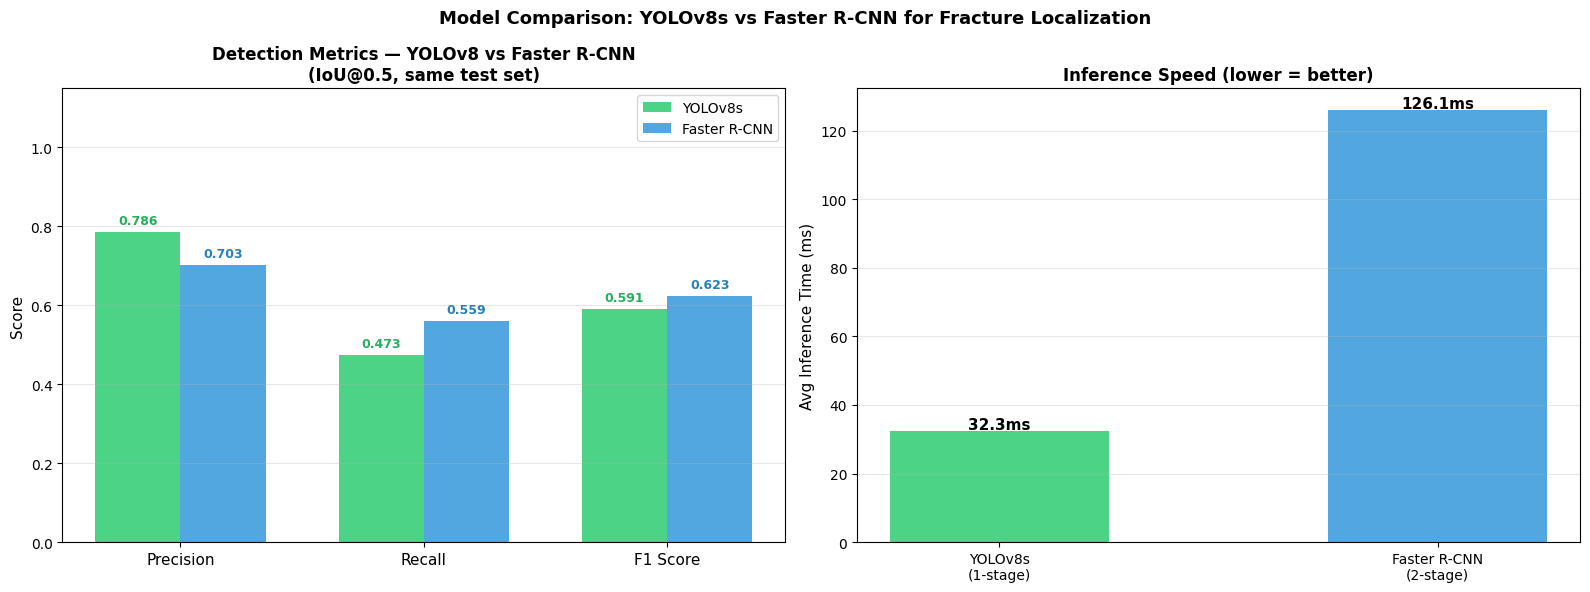

✅ Saved → comparison_chart.png


In [28]:
# ── Comparison bar chart ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x     = np.arange(3)
width = 0.35
labels_bar = ['Precision', 'Recall', 'F1 Score']
yolo_vals  = [prec_y, rec_y, f1_y]
frcnn_vals = [prec_f, rec_f, f1_f]

axes[0].bar(x - width/2, yolo_vals,  width, label='YOLOv8s',      color='#2ecc71', alpha=0.85)
axes[0].bar(x + width/2, frcnn_vals, width, label='Faster R-CNN', color='#3498db', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels_bar, fontsize=11)
axes[0].set_ylim(0, 1.15); axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('Detection Metrics — YOLOv8 vs Faster R-CNN\n(IoU@0.5, same test set)',
                   fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10); axes[0].grid(axis='y', alpha=0.3)
for i, (yv, fv) in enumerate(zip(yolo_vals, frcnn_vals)):
    axes[0].text(i-width/2, yv+0.02, f'{yv:.3f}', ha='center', fontsize=9, fontweight='bold', color='#27ae60')
    axes[0].text(i+width/2, fv+0.02, f'{fv:.3f}', ha='center', fontsize=9, fontweight='bold', color='#2980b9')

axes[1].bar(['YOLOv8s\n(1-stage)', 'Faster R-CNN\n(2-stage)'],
             [avg_yolo_time, avg_frcnn_time],
             color=['#2ecc71', '#3498db'], alpha=0.85, width=0.5)
axes[1].set_ylabel('Avg Inference Time (ms)', fontsize=11)
axes[1].set_title('Inference Speed (lower = better)', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, t in enumerate([avg_yolo_time, avg_frcnn_time]):
    axes[1].text(i, t+0.5, f'{t:.1f}ms', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Model Comparison: YOLOv8s vs Faster R-CNN for Fracture Localization',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FINAL_FIG_DIR / 'comparison_chart.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Saved → comparison_chart.png')


### Step 7.4 — Scientific Discussion

In [29]:
winner_prec = 'Faster R-CNN' if prec_f > prec_y else 'YOLOv8'
winner_rec  = 'Faster R-CNN' if rec_f  > rec_y  else 'YOLOv8'
winner_f1   = 'Faster R-CNN' if f1_f   > f1_y   else 'YOLOv8'
winner_spd  = 'YOLOv8' if avg_yolo_time < avg_frcnn_time else 'Faster R-CNN'
speedup     = avg_frcnn_time / avg_yolo_time if avg_yolo_time > 0 else 1.0

print('='*60)
print('  SCIENTIFIC ANALYSIS: YOLOv8s vs Faster R-CNN')
print('='*60)
print(f'  Precision winner:  {winner_prec}')
print(f'  Recall winner:     {winner_rec}')
print(f'  F1 winner:         {winner_f1}')
print(f'  Speed winner:      {winner_spd}  ({speedup:.1f}x faster)')
print()
print('  YOLOv8 (1-stage):')
print('    - Single forward pass -> lower latency')
print('    - Direct box regression from multi-scale features')
print('    - Better for real-time clinical screening tools')
print()
print('  Faster R-CNN (2-stage):')
print('    - Region Proposal Network -> RoI pooling -> classification')
print('    - More thorough localization, typically higher precision')
print('    - Preferred when false positives are costly')
print()
print('  Clinical relevance:')
print('    - For fracture detection, RECALL is more important than precision')
print('    - Missing a fracture (FN) is more dangerous than a false alarm (FP)')
print(f'    - Clinically preferred: {winner_rec} (higher recall = {max(rec_y, rec_f):.4f})')


  SCIENTIFIC ANALYSIS: YOLOv8s vs Faster R-CNN
  Precision winner:  YOLOv8
  Recall winner:     Faster R-CNN
  F1 winner:         Faster R-CNN
  Speed winner:      YOLOv8  (3.9x faster)

  YOLOv8 (1-stage):
    - Single forward pass -> lower latency
    - Direct box regression from multi-scale features
    - Better for real-time clinical screening tools

  Faster R-CNN (2-stage):
    - Region Proposal Network -> RoI pooling -> classification
    - More thorough localization, typically higher precision
    - Preferred when false positives are costly

  Clinical relevance:
    - For fracture detection, RECALL is more important than precision
    - Missing a fracture (FN) is more dangerous than a false alarm (FP)
    - Clinically preferred: Faster R-CNN (higher recall = 0.5591)


---
## 📁 Section 8 — Report Figures & Final Summary

In [30]:
# ── Save updated results summary ─────────────────────────────────
import pandas as pd

results_summary = {
    'Model':        ['EfficientNet-B3 (Stage 1)', 'YOLOv8s (Stage 2)', 'Faster R-CNN (Stage 2)'],
    'Task':         ['4-class classification', 'Fracture localization', 'Fracture localization'],
    'Test Accuracy':[f'{test_acc:.4f} ({test_acc:.2%})', 'N/A', 'N/A'],
    'Macro F1':     [f'{test_f1:.4f}', 'N/A', 'N/A'],
    'mAP@50':       ['N/A', f'{yolo_map50:.4f}', 'N/A (IoU-based eval)'],
    'Precision':    ['N/A', f'{prec_y:.4f}', f'{prec_f:.4f}'],
    'Recall':       ['N/A', f'{rec_y:.4f}', f'{rec_f:.4f}'],
    'F1 Score':     ['N/A', f'{f1_y:.4f}', f'{f1_f:.4f}'],
    'Avg Inf (ms)': ['N/A', f'{avg_yolo_time:.1f}', f'{avg_frcnn_time:.1f}'],
}
pd.DataFrame(results_summary).to_csv(FINAL_FIG_DIR/'final_results_summary.csv', index=False)

print('All figures saved to:', FINAL_FIG_DIR)
print()
for f in sorted(FINAL_FIG_DIR.glob('*')):
    print(f'  ✅ {f.name}')


All figures saved to: /content/drive/MyDrive/CV_project_v4/outputs/final_pipeline

  ✅ comparison_chart.png
  ✅ comparison_metrics.csv
  ✅ comparison_visual.png
  ✅ demo_single_image.png
  ✅ failure_cases.png
  ✅ final_results_summary.csv
  ✅ frcnn_demo.png
  ✅ frcnn_demo_single_image.png
  ✅ frcnn_failure_cases.png
  ✅ frcnn_full_pipeline.png
  ✅ frcnn_full_pipeline_visualization.png
  ✅ frcnn_gt_boxes.png
  ✅ frcnn_missed_detections.png
  ✅ frcnn_val_predictions.png
  ✅ full_pipeline_visualization.png
  ✅ gradcam_visualization.png
  ✅ test_classification_report.csv
  ✅ test_confusion_matrix.png
  ✅ yolo_demo.png
  ✅ yolo_full_pipeline.png
  ✅ yolo_gt_boxes.png
  ✅ yolo_missed_detections.png
  ✅ yolo_val_predictions.png
  ✅ yolo_vs_frcnn_chart.png
  ✅ yolo_vs_frcnn_comparison.png
  ✅ yolo_vs_frcnn_metrics.csv


In [31]:
print('╔'+'═'*64+'╗')
print('║'+' FULL PIPELINE COMPLETE — CV_project_v4'.center(64)+'║')
print('╠'+'═'*64+'╣')
print('║  PART 1: EfficientNet-B3 Classification                   ║')
print(f'║    Test Accuracy: {test_acc:.4f} ({test_acc:.2%})                       ║')
print(f'║    Test Macro F1: {test_f1:.4f}                                ║')
print('╠'+'═'*64+'╣')
print('║  PART 2: YOLOv8 Fracture Localization                     ║')
print(f'║    mAP@50:    {yolo_map50:.4f}                                    ║')
print(f'║    Precision: {prec_y:.4f} | Recall: {rec_y:.4f}               ║')
print('╠'+'═'*64+'╣')
print('║  PART 3: Faster R-CNN Fracture Localization               ║')
print(f'║    Precision: {prec_f:.4f} | Recall: {rec_f:.4f}               ║')
print(f'║    Speed: {avg_frcnn_time:.1f}ms vs YOLOv8 {avg_yolo_time:.1f}ms                 ║')
print('╠'+'═'*64+'╣')
print('║  DATASET: FracAtlas (Nature 2023) — Hand + Leg only       ║')
print('╚'+'═'*64+'╝')


╔════════════════════════════════════════════════════════════════╗
║             FULL PIPELINE COMPLETE — CV_project_v4             ║
╠════════════════════════════════════════════════════════════════╣
║  PART 1: EfficientNet-B3 Classification                   ║
║    Test Accuracy: 0.8663 (86.63%)                       ║
║    Test Macro F1: 0.7625                                ║
╠════════════════════════════════════════════════════════════════╣
║  PART 2: YOLOv8 Fracture Localization                     ║
║    mAP@50:    0.4058                                    ║
║    Precision: 0.7857 | Recall: 0.4731               ║
╠════════════════════════════════════════════════════════════════╣
║  PART 3: Faster R-CNN Fracture Localization               ║
║    Precision: 0.7027 | Recall: 0.5591               ║
║    Speed: 126.1ms vs YOLOv8 32.3ms                 ║
╠════════════════════════════════════════════════════════════════╣
║  DATASET: FracAtlas (Nature 2023) — Hand + Leg only       ║
╚══